In [48]:
#import sys
#sys.executable


In [47]:
#import sys
#!{sys.executable} -m pip install wordcloud


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

df = pd.read_csv("data_propre.csv")

# Conversions utiles
df["Date_Publication"] = pd.to_datetime(df["Date_Publication"], errors="coerce")
df["Score_CVSS"] = pd.to_numeric(df["Score_CVSS"], errors="coerce")
df["Score_EPSS"] = pd.to_numeric(df["Score_EPSS"], errors="coerce")
df["EPSS_Percentile"] = pd.to_numeric(df["EPSS_Percentile"], errors="coerce")

df.head()


,ID_CVE,url,Éditeur,Produit,Versions,Lien_Bulletin,ID_ANSSI,Titre_ANSSI,Date_Publication,Description,Score_CVSS,Gravite_CVSS,Vecteur_CVSS,Type_CWE,Score_EPSS,EPSS_Percentile,Description_Tech,Type_de_Bulletin
0,CVE-2022-40242,https://www.cve.org/CVERecord?id=CVE-2022-40242,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-798,0.00137,0.34248,MegaRAC Default Credentials Vulnerability,Alerte
1,CVE-2022-40242,https://www.cve.org/CVERecord?id=CVE-2022-40242,NaN,NaN,AMI MegaRAC SPx-12 versions 0 à SPx-12-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-798,0.00137,0.34248,MegaRAC Default Credentials Vulnerability,Alerte
2,CVE-2022-40259,https://www.cve.org/CVERecord?id=CVE-2022-40259,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,8.3,HIGH,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,CWE-798,0.00302,0.53102,MegaRAC Default Credentials Vulnerability,Alerte
3,CVE-2022-40259,https://www.cve.org/CVERecord?id=CVE-2022-40259,NaN,NaN,AMI MegaRAC SPx-12 versions 0 à SPx-12-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,8.3,HIGH,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,CWE-798,0.00302,0.53102,MegaRAC Default Credentials Vulnerability,Alerte
4,CVE-2022-2827,https://www.cve.org/CVERecord?id=CVE-2022-2827,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-200,0.16108,0.94572,AMI MegaRAC User Enumeration Vulnerability,Alerte


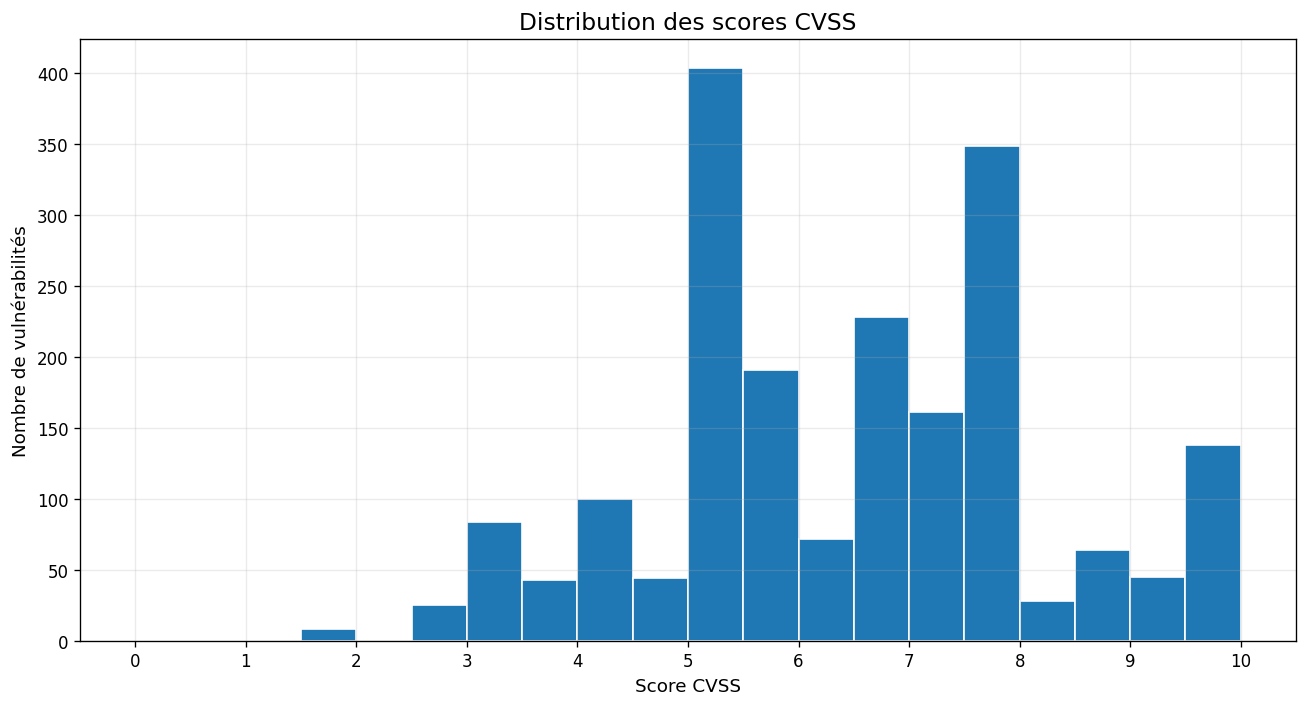

In [11]:
x = df["Score_CVSS"].dropna()
bins = np.arange(0, 10.5, 0.5)

plt.figure()
plt.hist(x, bins=bins, edgecolor="white", linewidth=1.0)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.xticks(np.arange(0, 11, 1))
plt.tight_layout()
plt.show()



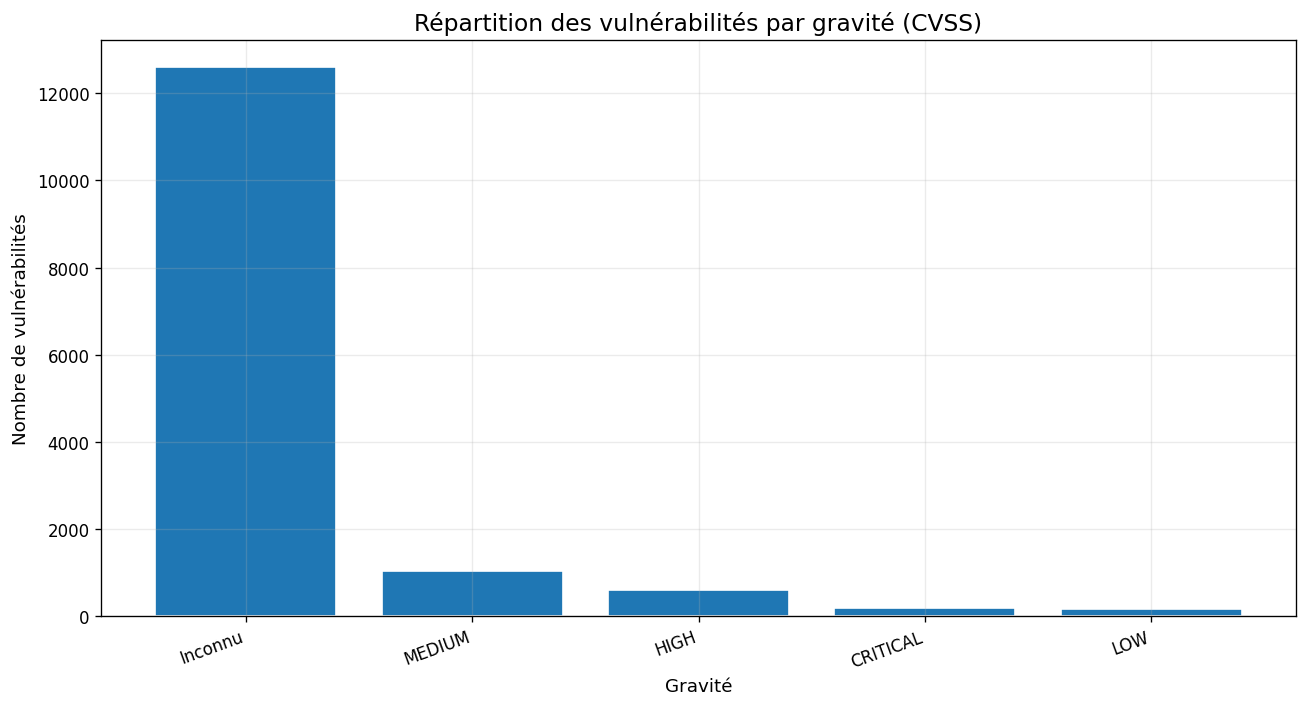

In [12]:
counts = (
    df["Gravite_CVSS"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
)

plt.figure()
plt.bar(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title("Répartition des vulnérabilités par gravité (CVSS)")
plt.xlabel("Gravité")
plt.ylabel("Nombre de vulnérabilités")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


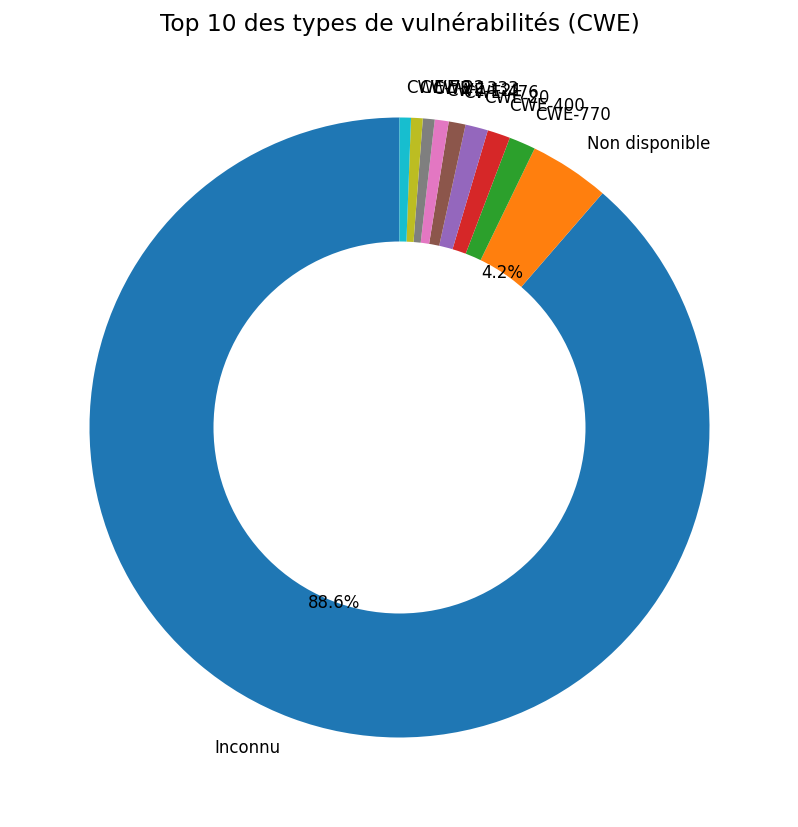

In [13]:
top_n = 10
counts = (
    df["Type_CWE"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
    .head(top_n)
)

plt.figure(figsize=(10, 7), dpi=120)
plt.pie(
    counts.values,
    labels=counts.index,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90
)
centre = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre)
plt.title(f"Top {top_n} des types de vulnérabilités (CWE)")
plt.tight_layout()
plt.show()


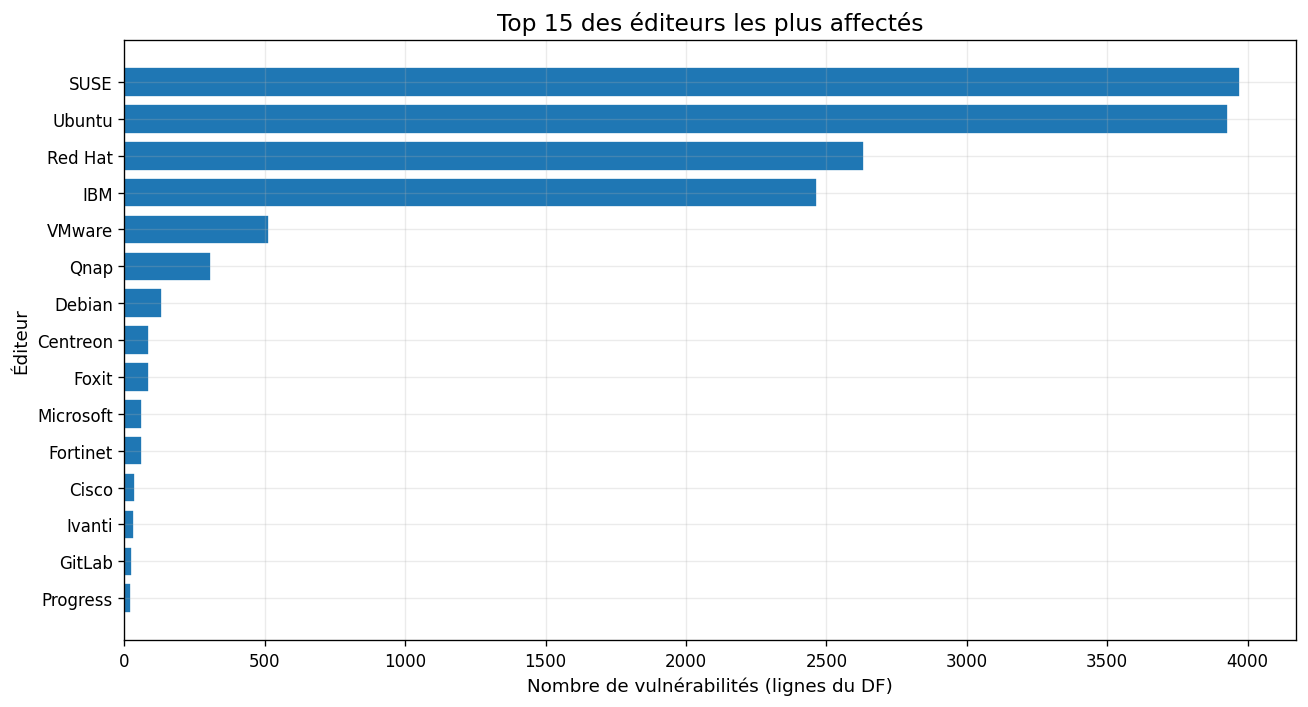

In [14]:
top_n = 15
counts = (
    df["Éditeur"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
    .head(top_n)
    .sort_values()
)

plt.figure()
plt.barh(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title(f"Top {top_n} des éditeurs les plus affectés")
plt.xlabel("Nombre de vulnérabilités (lignes du DF)")
plt.ylabel("Éditeur")
plt.tight_layout()
plt.show()


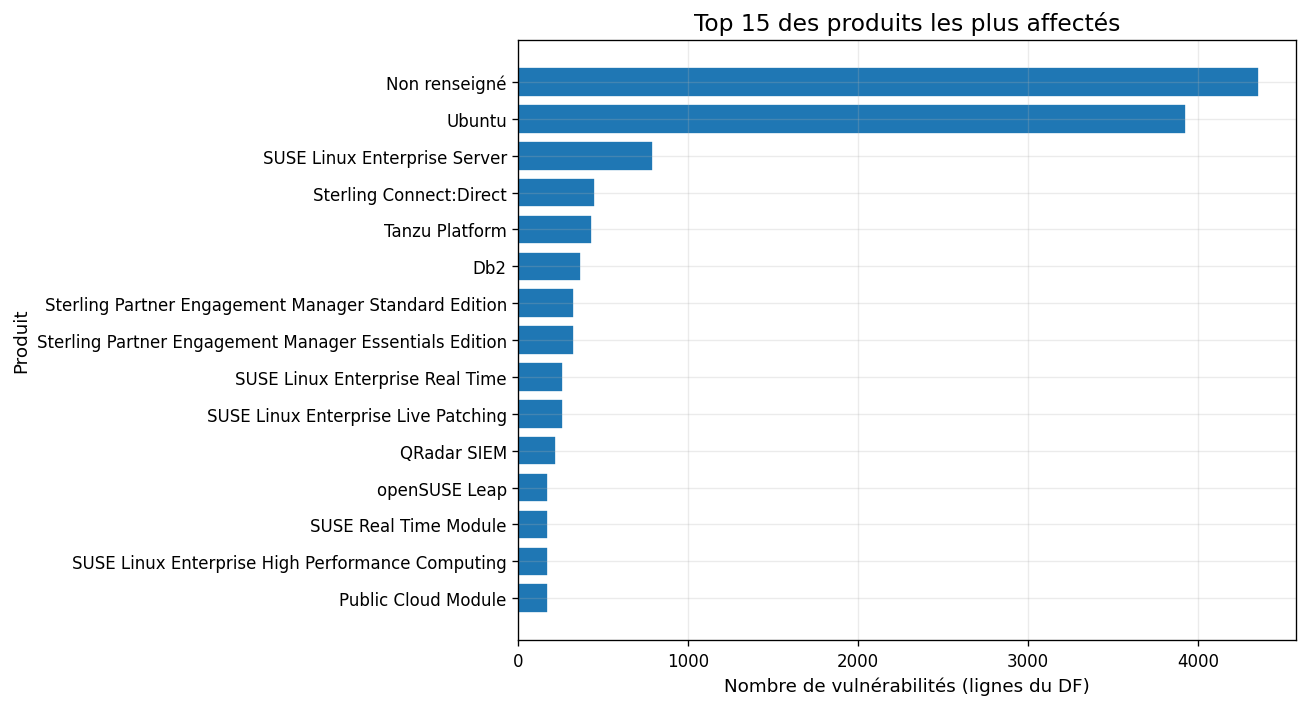

In [15]:
top_n = 15
counts = (
    df["Produit"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
    .head(top_n)
    .sort_values()
)

plt.figure()
plt.barh(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title(f"Top {top_n} des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités (lignes du DF)")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()


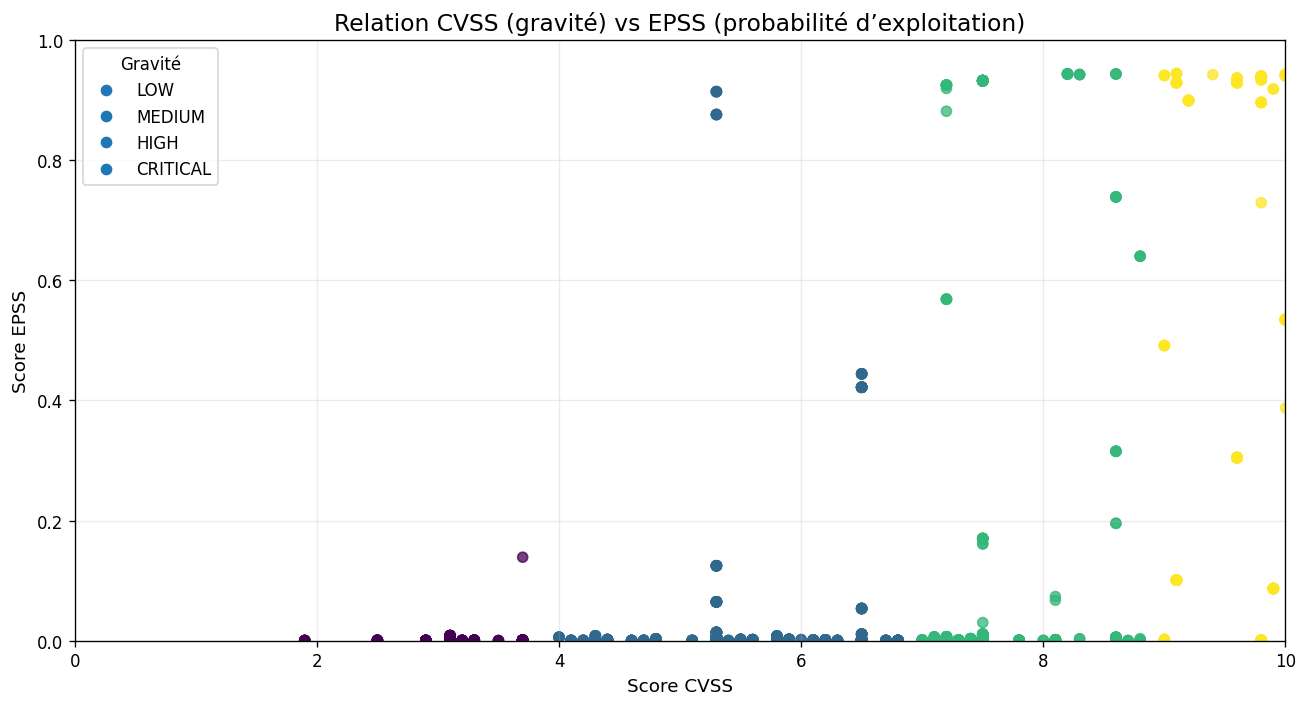

In [16]:
tmp = df[["Score_CVSS", "Score_EPSS", "Gravite_CVSS"]].dropna()

# mapping gravité -> code couleur (matplotlib choisit la palette automatiquement)
order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

code = tmp["Gravite_CVSS"].map({k:i for i,k in enumerate(order)}).fillna(len(order)).astype(int)

plt.figure()
sc = plt.scatter(tmp["Score_CVSS"], tmp["Score_EPSS"], c=code, alpha=0.75)

plt.title("Relation CVSS (gravité) vs EPSS (probabilité d’exploitation)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.xlim(0, 10)
plt.ylim(0, 1)

# légende manuelle
handles = []
labels = []
for k in order:
    if k in tmp["Gravite_CVSS"].values:
        labels.append(k)
        handles.append(plt.Line2D([0],[0], marker='o', linestyle='', label=k))
plt.legend(handles=handles, title="Gravité", loc="best")

plt.tight_layout()
plt.show()


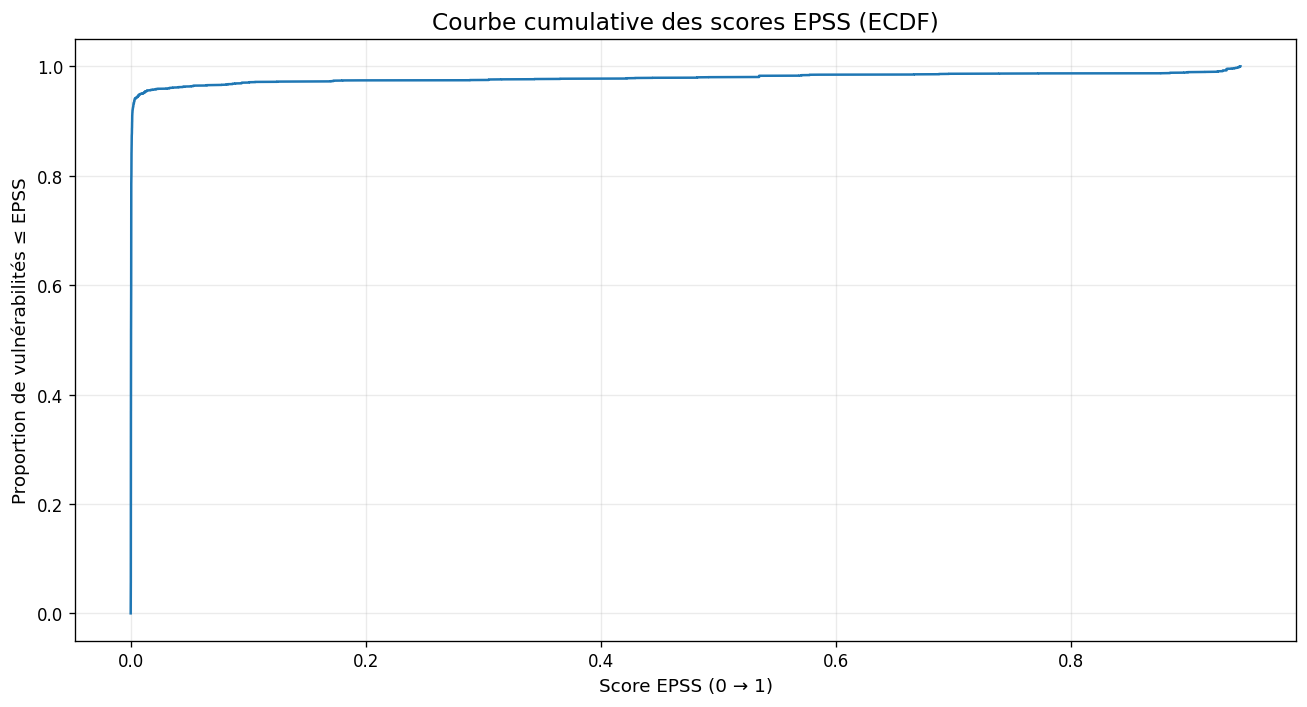

In [17]:
x = df["Score_EPSS"].dropna().sort_values()
y = np.arange(1, len(x) + 1) / len(x)

plt.figure()
plt.plot(x.values, y)
plt.title("Courbe cumulative des scores EPSS (ECDF)")
plt.xlabel("Score EPSS (0 → 1)")
plt.ylabel("Proportion de vulnérabilités ≤ EPSS")
plt.tight_layout()
plt.show()


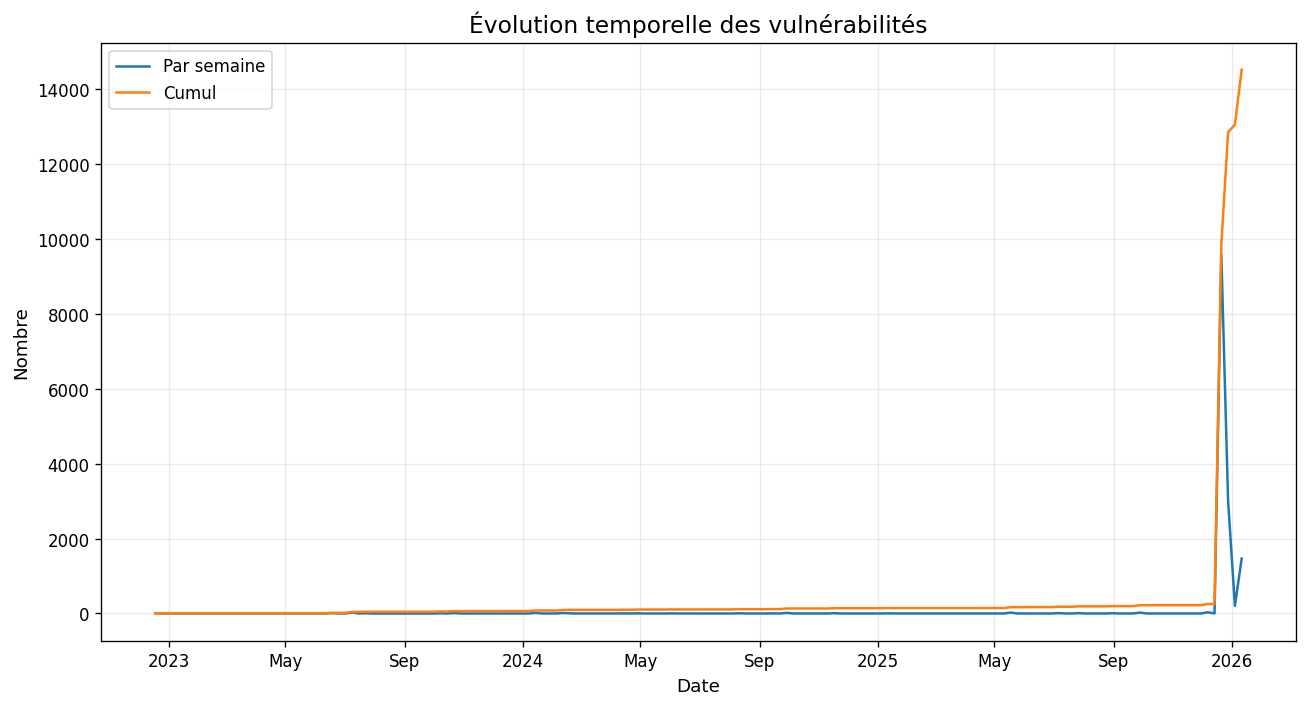

In [18]:
tmp = df[["Date_Publication"]].dropna().sort_values("Date_Publication")
weekly = tmp.groupby(pd.Grouper(key="Date_Publication", freq="W")).size().rename("count").reset_index()
weekly["cumulative"] = weekly["count"].cumsum()

plt.figure()
plt.plot(weekly["Date_Publication"], weekly["count"], label="Par semaine")
plt.plot(weekly["Date_Publication"], weekly["cumulative"], label="Cumul")

plt.title("Évolution temporelle des vulnérabilités")
plt.xlabel("Date")
plt.ylabel("Nombre")
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

plt.tight_layout()
plt.show()


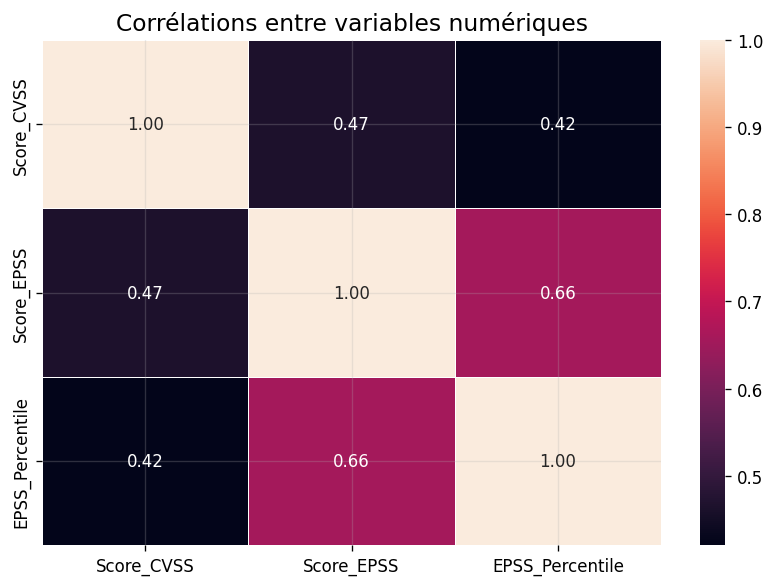

In [20]:
num_cols = ["Score_CVSS", "Score_EPSS", "EPSS_Percentile"]
num_df = df[num_cols].dropna(how="all")
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(7, 5), dpi=120)
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)


plt.title("Corrélations entre variables numériques")
plt.tight_layout()
plt.show()


C:\Users\nayls\AppData\Local\Temp\ipykernel_1816\222715528.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=top_types, showmeans=True)


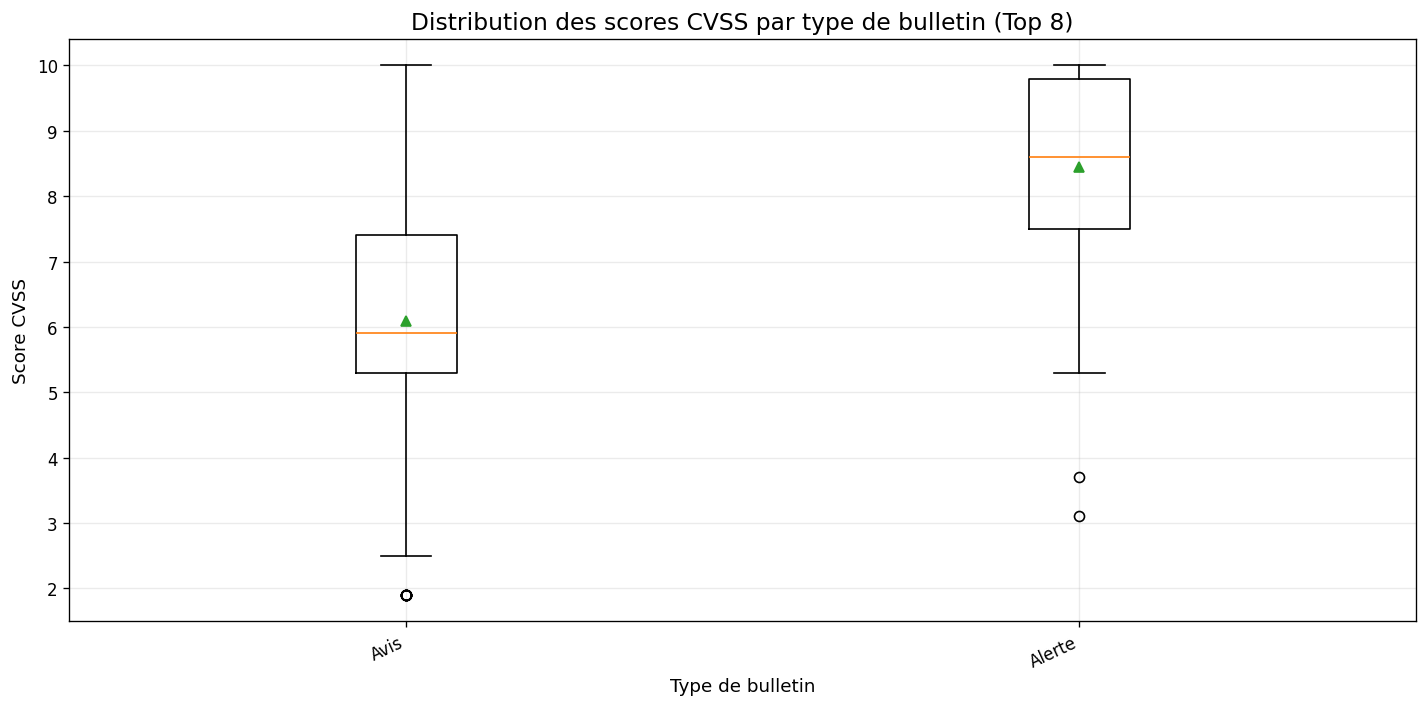

In [21]:
tmp = df[["Type_de_Bulletin", "Score_CVSS"]].dropna()
# prend les 8 types les plus fréquents pour lisibilité
top_types = tmp["Type_de_Bulletin"].value_counts().head(8).index
tmp = tmp[tmp["Type_de_Bulletin"].isin(top_types)]

groups = [tmp.loc[tmp["Type_de_Bulletin"] == t, "Score_CVSS"].values for t in top_types]

plt.figure(figsize=(12, 6), dpi=120)
plt.boxplot(groups, labels=top_types, showmeans=True)
plt.title("Distribution des scores CVSS par type de bulletin (Top 8)")
plt.xlabel("Type de bulletin")
plt.ylabel("Score CVSS")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


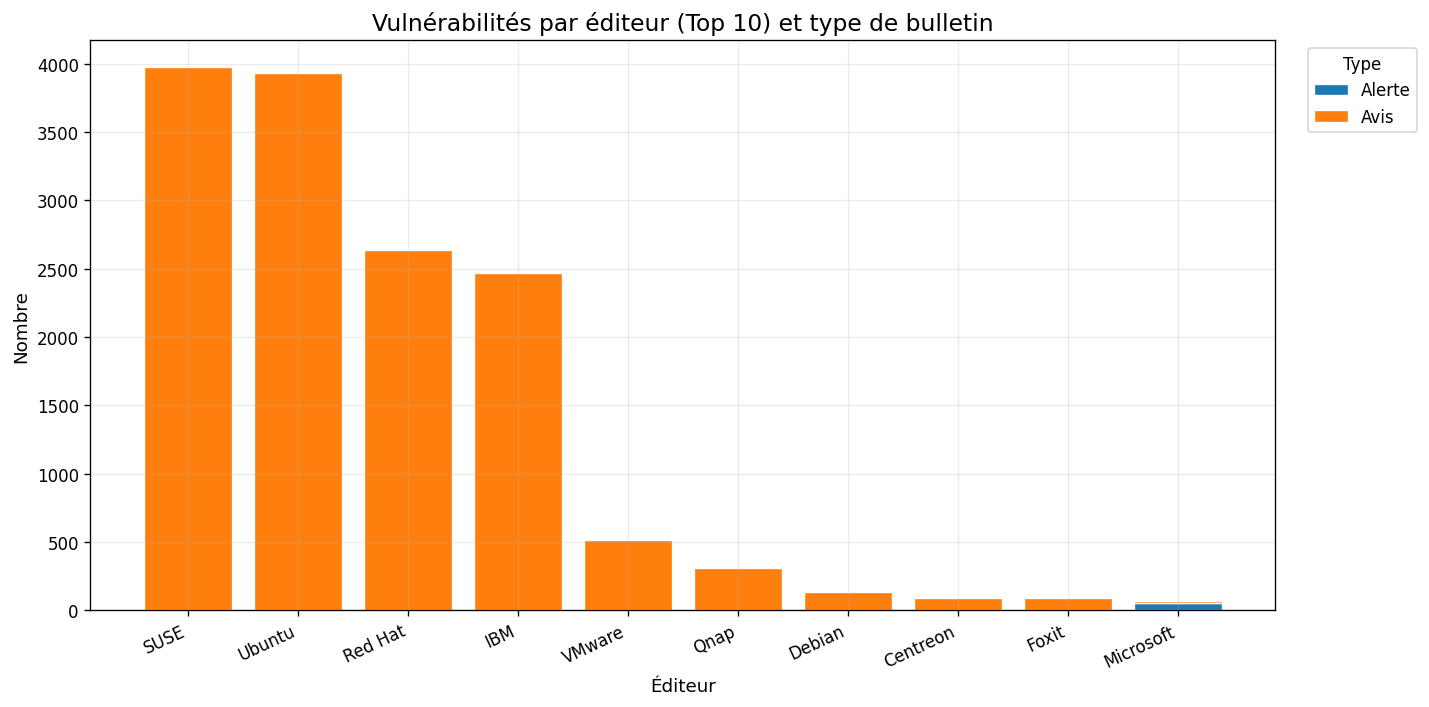

In [22]:
top_n = 10
tmp = df[["Éditeur", "Type_de_Bulletin"]].dropna()

top_vendors = tmp["Éditeur"].value_counts().head(top_n).index
tmp = tmp[tmp["Éditeur"].isin(top_vendors)]

pivot = pd.crosstab(tmp["Éditeur"], tmp["Type_de_Bulletin"]).loc[top_vendors]

plt.figure(figsize=(12, 6), dpi=120)
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col].values, bottom=bottom, label=col, edgecolor="white", linewidth=0.8)
    bottom += pivot[col].values

plt.title(f"Vulnérabilités par éditeur (Top {top_n}) et type de bulletin")
plt.xlabel("Éditeur")
plt.ylabel("Nombre")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


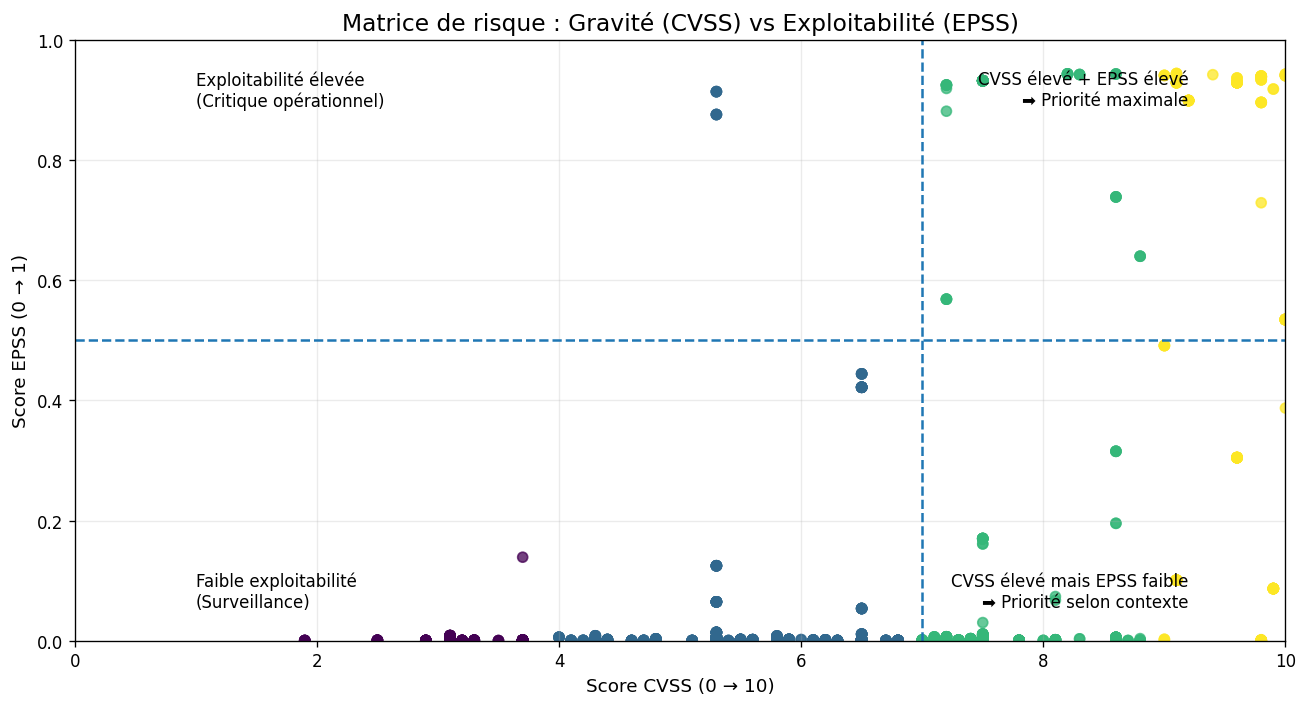

In [23]:
tmp = df[["Score_CVSS", "Score_EPSS", "Gravite_CVSS"]].dropna().copy()

# Seuils (ajuste si besoin)
cvss_thr = 7.0
epss_thr = 0.5

# Couleur par gravité (si tu as Gravite_CVSS propre)
severity = tmp["Gravite_CVSS"].astype(str).str.upper()
map_code = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "CRITICAL": 3}
c = severity.map(map_code).fillna(4).astype(int)

plt.figure()
plt.scatter(tmp["Score_CVSS"], tmp["Score_EPSS"], c=c, alpha=0.75)

plt.axvline(cvss_thr, linestyle="--")
plt.axhline(epss_thr, linestyle="--")

plt.text(1, 0.95, "Exploitabilité élevée\n(Critique opérationnel)", va="top")
plt.text(1, 0.05, "Faible exploitabilité\n(Surveillance)", va="bottom")
plt.text(9.2, 0.95, "CVSS élevé + EPSS élevé\n➡ Priorité maximale", va="top", ha="right")
plt.text(9.2, 0.05, "CVSS élevé mais EPSS faible\n➡ Priorité selon contexte", va="bottom", ha="right")

plt.title("Matrice de risque : Gravité (CVSS) vs Exploitabilité (EPSS)")
plt.xlabel("Score CVSS (0 → 10)")
plt.ylabel("Score EPSS (0 → 1)")
plt.xlim(0, 10)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


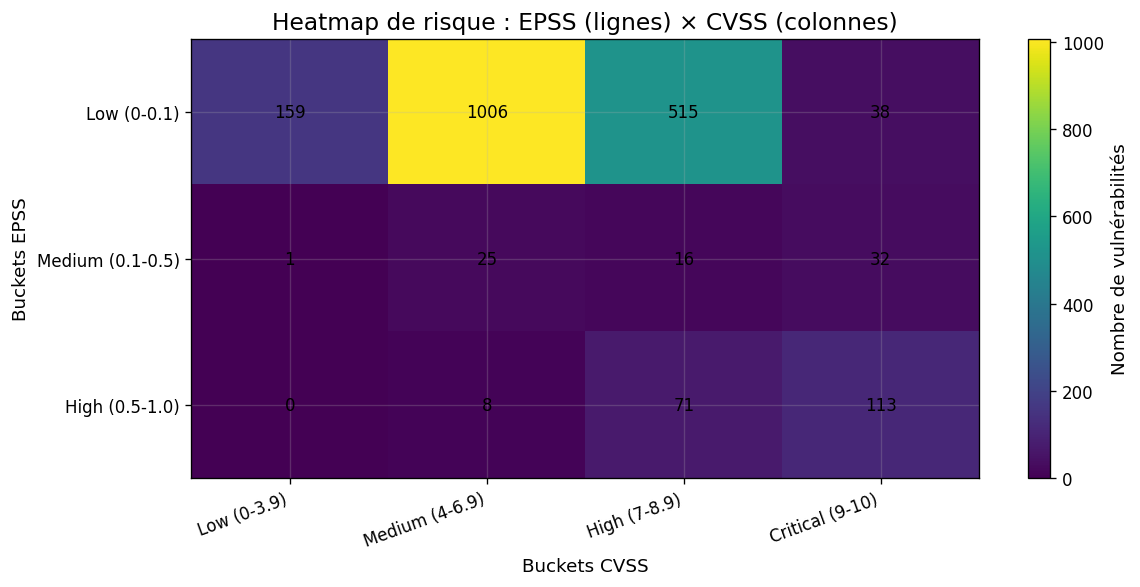

In [24]:
tmp = df[["Score_CVSS", "Score_EPSS"]].dropna().copy()

# Buckets CVSS (standard)
cvss_bins = [0, 4, 7, 9, 10.01]
cvss_lbls = ["Low (0-3.9)", "Medium (4-6.9)", "High (7-8.9)", "Critical (9-10)"]
tmp["cvss_bucket"] = pd.cut(tmp["Score_CVSS"], bins=cvss_bins, labels=cvss_lbls, right=False)

# Buckets EPSS (tu peux ajuster)
epss_bins = [0, 0.1, 0.5, 1.01]
epss_lbls = ["Low (0-0.1)", "Medium (0.1-0.5)", "High (0.5-1.0)"]
tmp["epss_bucket"] = pd.cut(tmp["Score_EPSS"], bins=epss_bins, labels=epss_lbls, right=False)

pivot = pd.crosstab(tmp["epss_bucket"], tmp["cvss_bucket"]).reindex(index=epss_lbls, columns=cvss_lbls).fillna(0)

plt.figure(figsize=(10, 5), dpi=120)
im = plt.imshow(pivot.values, aspect="auto")
plt.title("Heatmap de risque : EPSS (lignes) × CVSS (colonnes)")
plt.xlabel("Buckets CVSS")
plt.ylabel("Buckets EPSS")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=20, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(im, label="Nombre de vulnérabilités")

# annotations
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, int(pivot.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


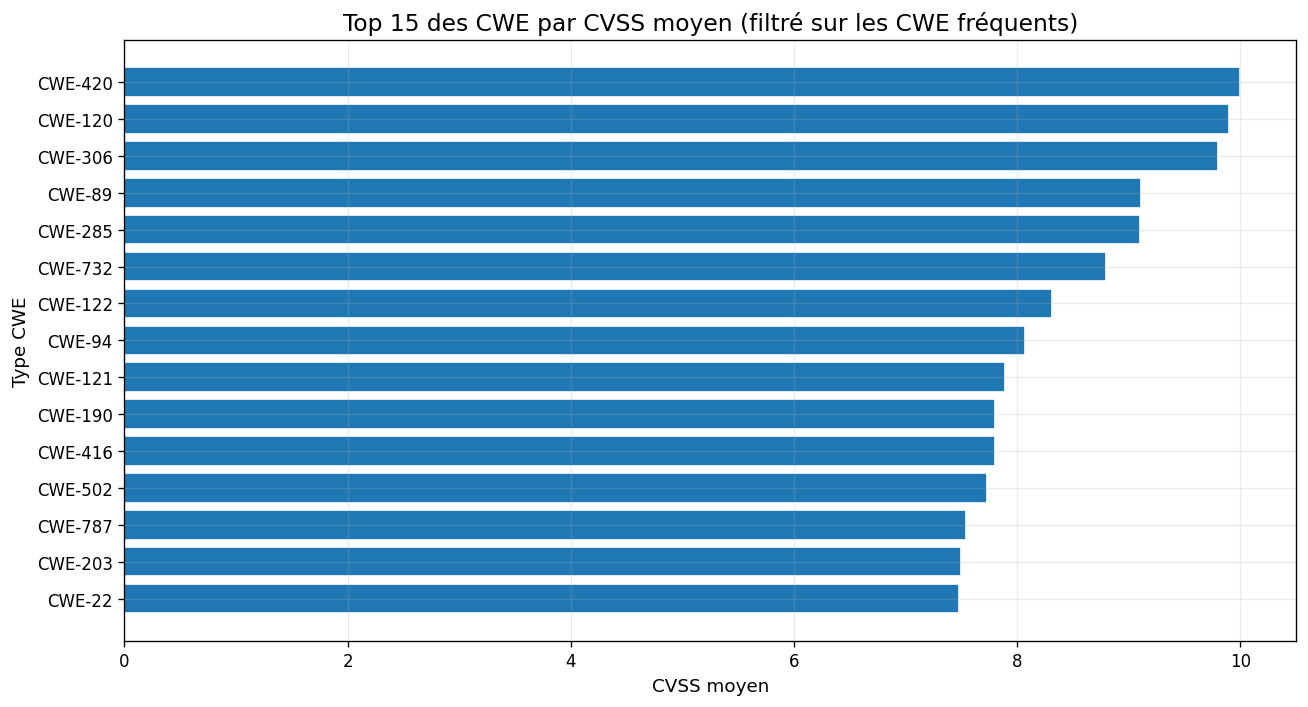

In [25]:
tmp = df[["Type_CWE", "Score_CVSS"]].dropna().copy()
tmp["Type_CWE"] = tmp["Type_CWE"].astype(str).replace({"": "Non renseigné"})

# On garde seulement les CWE suffisamment fréquents (sinon c'est bruité)
min_count = 5
stats = tmp.groupby("Type_CWE")["Score_CVSS"].agg(["count", "mean"]).reset_index()
stats = stats[stats["count"] >= min_count].sort_values("mean", ascending=False).head(15)
stats = stats.sort_values("mean")  # pour barh lisible

plt.figure()
plt.barh(stats["Type_CWE"], stats["mean"], edgecolor="white", linewidth=1.0)
plt.title("Top 15 des CWE par CVSS moyen (filtré sur les CWE fréquents)")
plt.xlabel("CVSS moyen")
plt.ylabel("Type CWE")
plt.tight_layout()
plt.show()


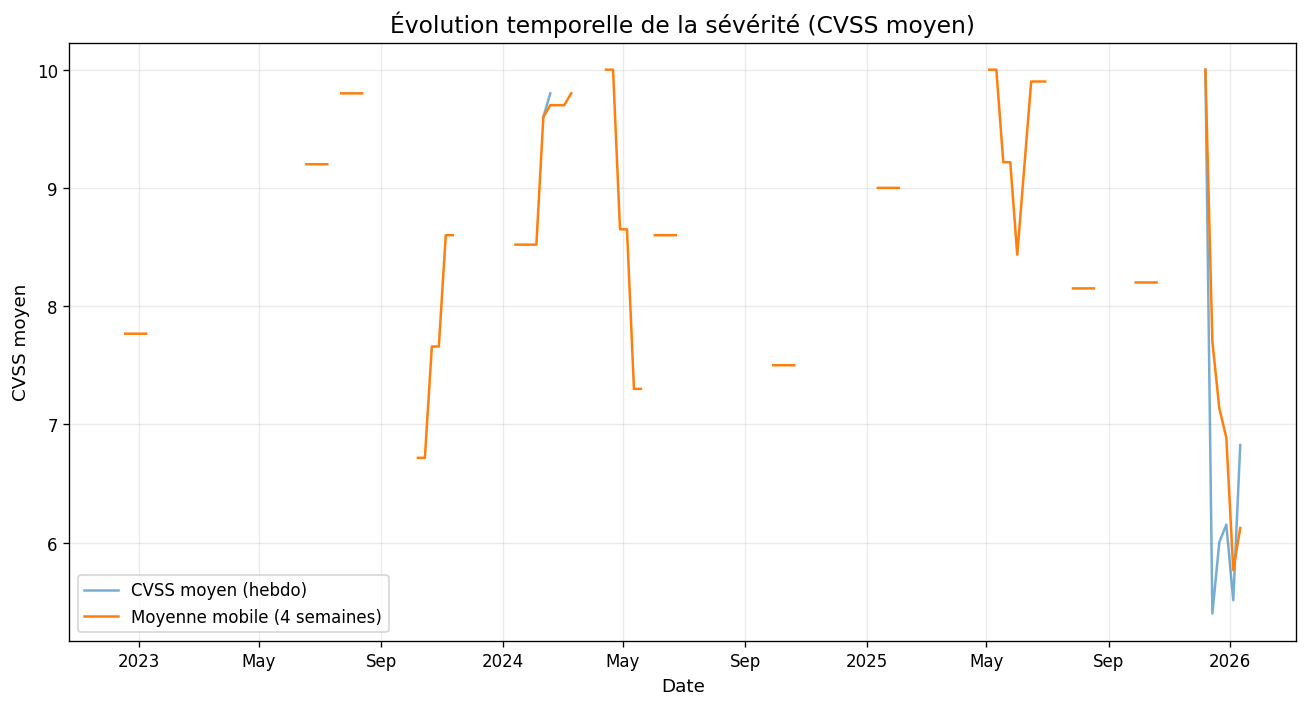

In [26]:
tmp = df[["Date_Publication", "Score_CVSS"]].dropna().copy()
tmp = tmp.sort_values("Date_Publication")

# Agrégation par semaine : CVSS moyen hebdo
weekly = tmp.groupby(pd.Grouper(key="Date_Publication", freq="W"))["Score_CVSS"].mean().rename("cvss_mean").reset_index()

# Moyenne mobile (sur 4 semaines)
window = 4
weekly["cvss_mean_roll"] = weekly["cvss_mean"].rolling(window=window, min_periods=1).mean()

plt.figure()
plt.plot(weekly["Date_Publication"], weekly["cvss_mean"], label="CVSS moyen (hebdo)", alpha=0.6)
plt.plot(weekly["Date_Publication"], weekly["cvss_mean_roll"], label=f"Moyenne mobile ({window} semaines)")

plt.title("Évolution temporelle de la sévérité (CVSS moyen)")
plt.xlabel("Date")
plt.ylabel("CVSS moyen")
plt.legend()

loc = mdates.AutoDateLocator()
plt.gca().xaxis.set_major_locator(loc)
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

plt.tight_layout()
plt.show()


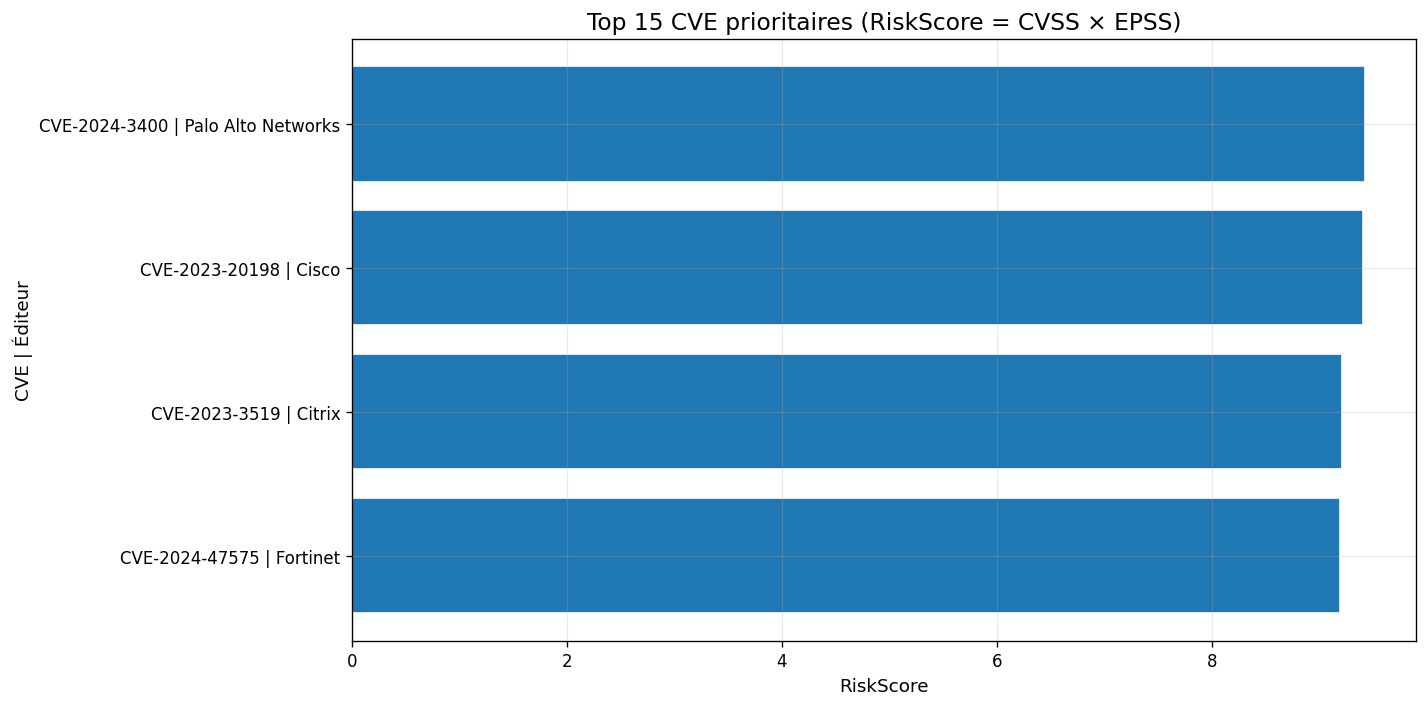

,ID_CVE,Éditeur,Produit,Score_CVSS,Score_EPSS,RiskScore,Lien_Bulletin
184,CVE-2024-47575,Fortinet,FortiManager,9.8,0.93846,9.196908,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
182,CVE-2024-47575,Fortinet,FortiManager,9.8,0.93846,9.196908,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
85,CVE-2023-3519,Citrix,NetScaler ADC,9.8,0.93993,9.211314,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
84,CVE-2023-3519,Citrix,NaN,9.8,0.93993,9.211314,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
86,CVE-2023-3519,Citrix,NaN,9.8,0.93993,9.211314,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
83,CVE-2023-3519,Citrix,NetScaler ADC,9.8,0.93993,9.211314,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
87,CVE-2023-3519,Citrix,NetScaler ADC,9.8,0.93993,9.211314,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
97,CVE-2023-20198,Cisco,IOS XE,10.0,0.94069,9.406900,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
95,CVE-2023-20198,Cisco,IOS XE,10.0,0.94069,9.406900,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...
94,CVE-2023-20198,Cisco,IOS XE,10.0,0.94069,9.406900,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...


In [27]:
tmp = df[["ID_CVE", "Éditeur", "Produit", "Score_CVSS", "Score_EPSS", "Lien_Bulletin"]].dropna(subset=["Score_CVSS", "Score_EPSS"]).copy()

# Score composite simple (tu peux aussi tester CVSS*(1+EPSS) ou CVSS*EPSS_Percentile/100)
tmp["RiskScore"] = tmp["Score_CVSS"] * tmp["Score_EPSS"]

top_n = 15
top = tmp.sort_values("RiskScore", ascending=False).head(top_n).copy()

# Label court lisible
top["Label"] = top["ID_CVE"].astype(str) + " | " + top["Éditeur"].astype(str)

top = top.sort_values("RiskScore")  # barh

plt.figure(figsize=(12, 6), dpi=120)
plt.barh(top["Label"], top["RiskScore"], edgecolor="white", linewidth=1.0)
plt.title(f"Top {top_n} CVE prioritaires (RiskScore = CVSS × EPSS)")
plt.xlabel("RiskScore")
plt.ylabel("CVE | Éditeur")

plt.tight_layout()
plt.show()

# (Optionnel) afficher le tableau des top CVE pour ton rapport
top[["ID_CVE", "Éditeur", "Produit", "Score_CVSS", "Score_EPSS", "RiskScore", "Lien_Bulletin"]]


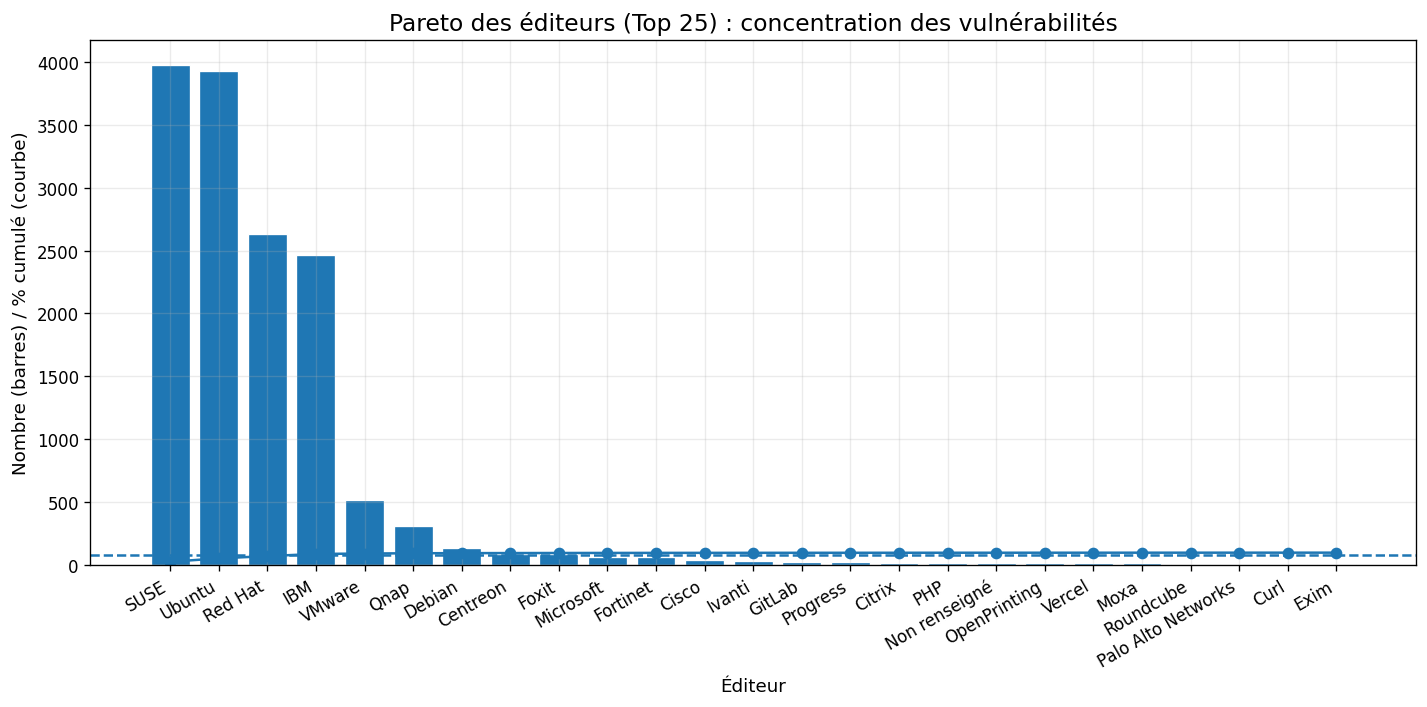

In [28]:
tmp = df["Éditeur"].fillna("Non renseigné").astype(str).replace({"": "Non renseigné"})
counts = tmp.value_counts()

pareto = counts.reset_index()
pareto.columns = ["Éditeur", "count"]
pareto["cum_pct"] = pareto["count"].cumsum() / pareto["count"].sum() * 100

top_n = 25
p = pareto.head(top_n)

plt.figure(figsize=(12, 6), dpi=120)
plt.bar(p["Éditeur"], p["count"], edgecolor="white", linewidth=0.8)
plt.plot(p["Éditeur"], p["cum_pct"], marker="o")
plt.axhline(80, linestyle="--")
plt.title(f"Pareto des éditeurs (Top {top_n}) : concentration des vulnérabilités")
plt.xlabel("Éditeur")
plt.ylabel("Nombre (barres) / % cumulé (courbe)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


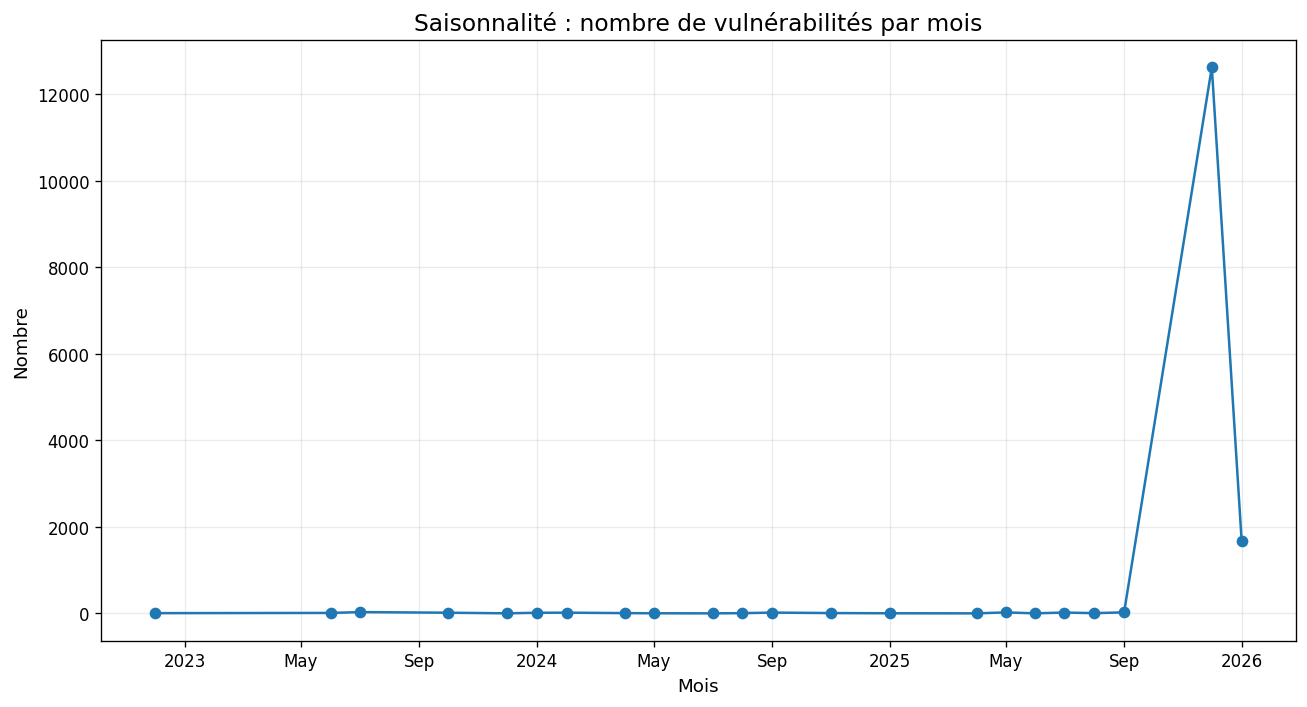

In [29]:
tmp = df[["Date_Publication"]].dropna().copy()
tmp["month"] = tmp["Date_Publication"].dt.to_period("M").dt.to_timestamp()

monthly = tmp.groupby("month").size().reset_index(name="count")

plt.figure()
plt.plot(monthly["month"], monthly["count"], marker="o")
plt.title("Saisonnalité : nombre de vulnérabilités par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre")
loc = mdates.AutoDateLocator()
plt.gca().xaxis.set_major_locator(loc)
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
plt.tight_layout()
plt.show()


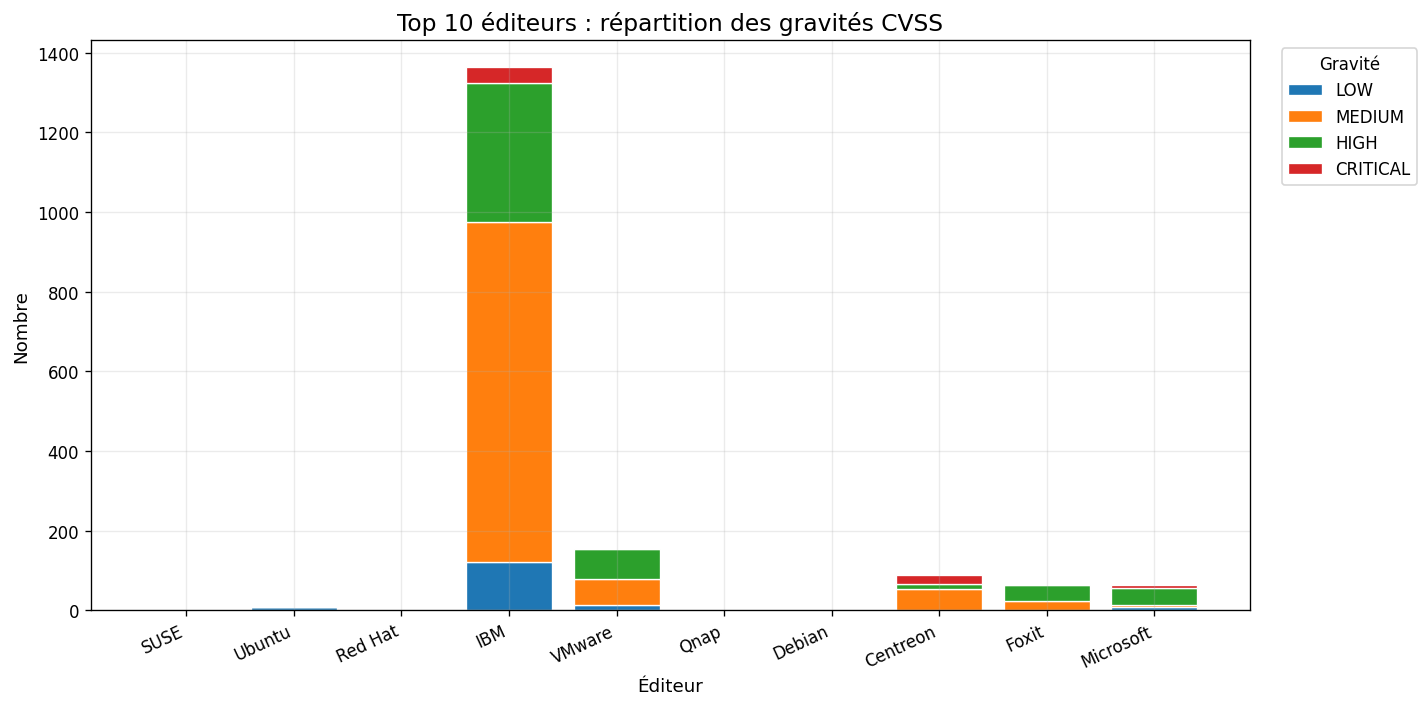

In [30]:
tmp = df[["Éditeur", "Gravite_CVSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

top_v = tmp["Éditeur"].value_counts().head(10).index
tmp = tmp[tmp["Éditeur"].isin(top_v)]

pivot = pd.crosstab(tmp["Éditeur"], tmp["Gravite_CVSS"])
# s'assure d'avoir des colonnes attendues
for col in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["LOW","MEDIUM","HIGH","CRITICAL"]].loc[top_v]

plt.figure(figsize=(12, 6), dpi=120)
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col].values, bottom=bottom, label=col, edgecolor="white", linewidth=0.8)
    bottom += pivot[col].values

plt.title("Top 10 éditeurs : répartition des gravités CVSS")
plt.xlabel("Éditeur")
plt.ylabel("Nombre")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


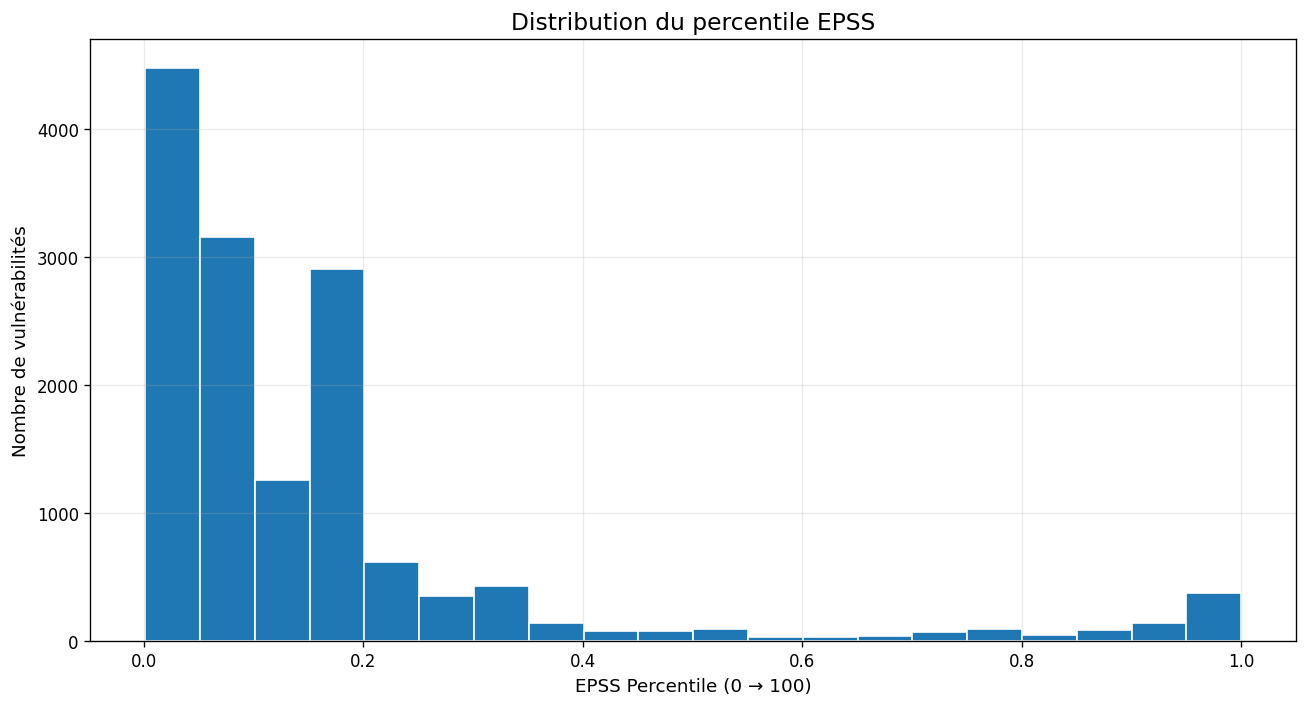

In [31]:
x = df["EPSS_Percentile"].dropna()

plt.figure()
plt.hist(x, bins=20, edgecolor="white", linewidth=1.0)
plt.title("Distribution du percentile EPSS")
plt.xlabel("EPSS Percentile (0 → 100)")
plt.ylabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.show()


C:\Users\nayls\AppData\Local\Temp\ipykernel_1816\414691177.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order, showmeans=True)


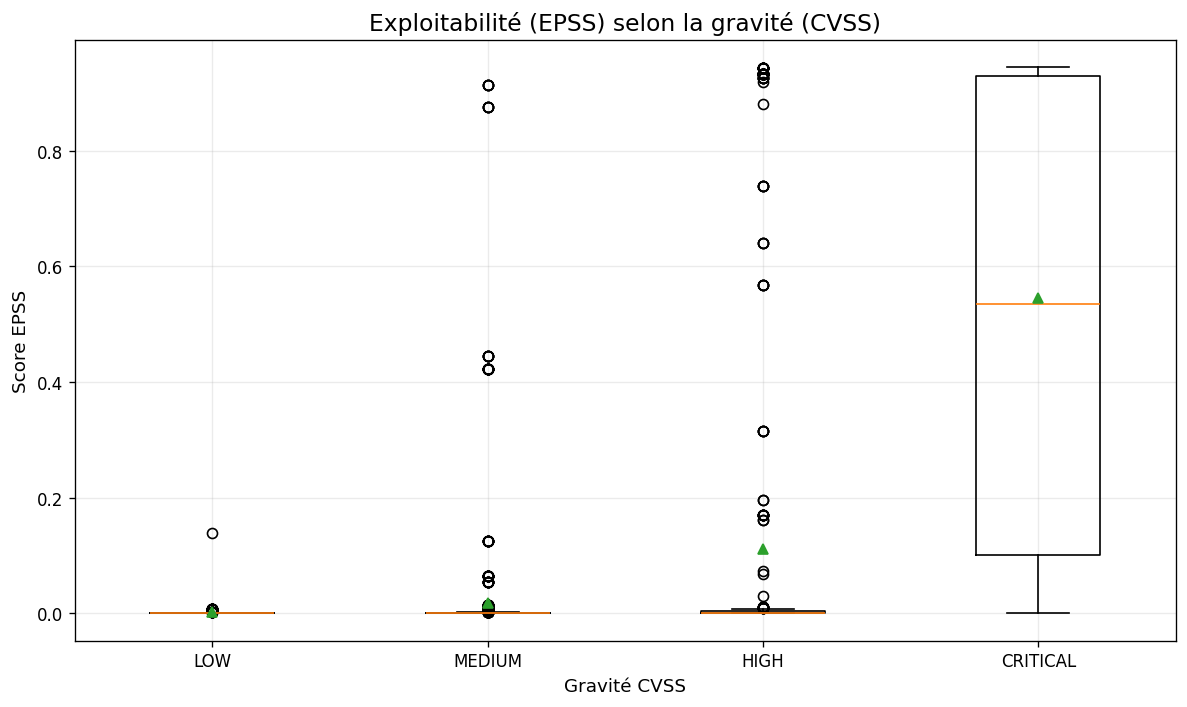

In [32]:
tmp = df[["Gravite_CVSS", "Score_EPSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
tmp = tmp[tmp["Gravite_CVSS"].isin(order)]

groups = [tmp.loc[tmp["Gravite_CVSS"] == g, "Score_EPSS"].values for g in order]

plt.figure(figsize=(10, 6), dpi=120)
plt.boxplot(groups, labels=order, showmeans=True)
plt.title("Exploitabilité (EPSS) selon la gravité (CVSS)")
plt.xlabel("Gravité CVSS")
plt.ylabel("Score EPSS")
plt.tight_layout()
plt.show()


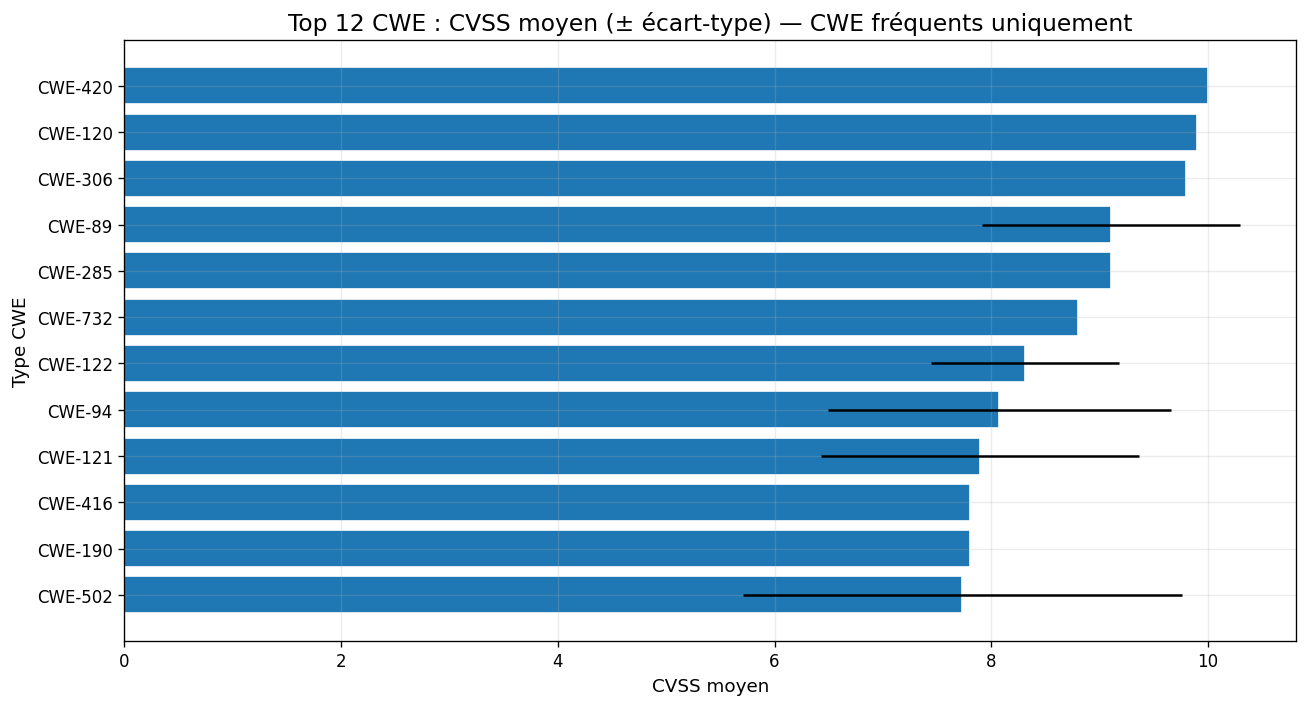

In [33]:
tmp = df[["Type_CWE", "Score_CVSS"]].dropna().copy()
tmp["Type_CWE"] = tmp["Type_CWE"].astype(str).replace({"": "Non renseigné"})

stats = tmp.groupby("Type_CWE")["Score_CVSS"].agg(["count", "mean", "std"]).reset_index()
stats = stats[stats["count"] >= 5].sort_values("mean", ascending=False).head(12)
stats = stats.sort_values("mean")

plt.figure(figsize=(11, 6), dpi=120)
plt.barh(stats["Type_CWE"], stats["mean"], xerr=stats["std"], edgecolor="white", linewidth=1.0)
plt.title("Top 12 CWE : CVSS moyen (± écart-type) — CWE fréquents uniquement")
plt.xlabel("CVSS moyen")
plt.ylabel("Type CWE")
plt.tight_layout()
plt.show()


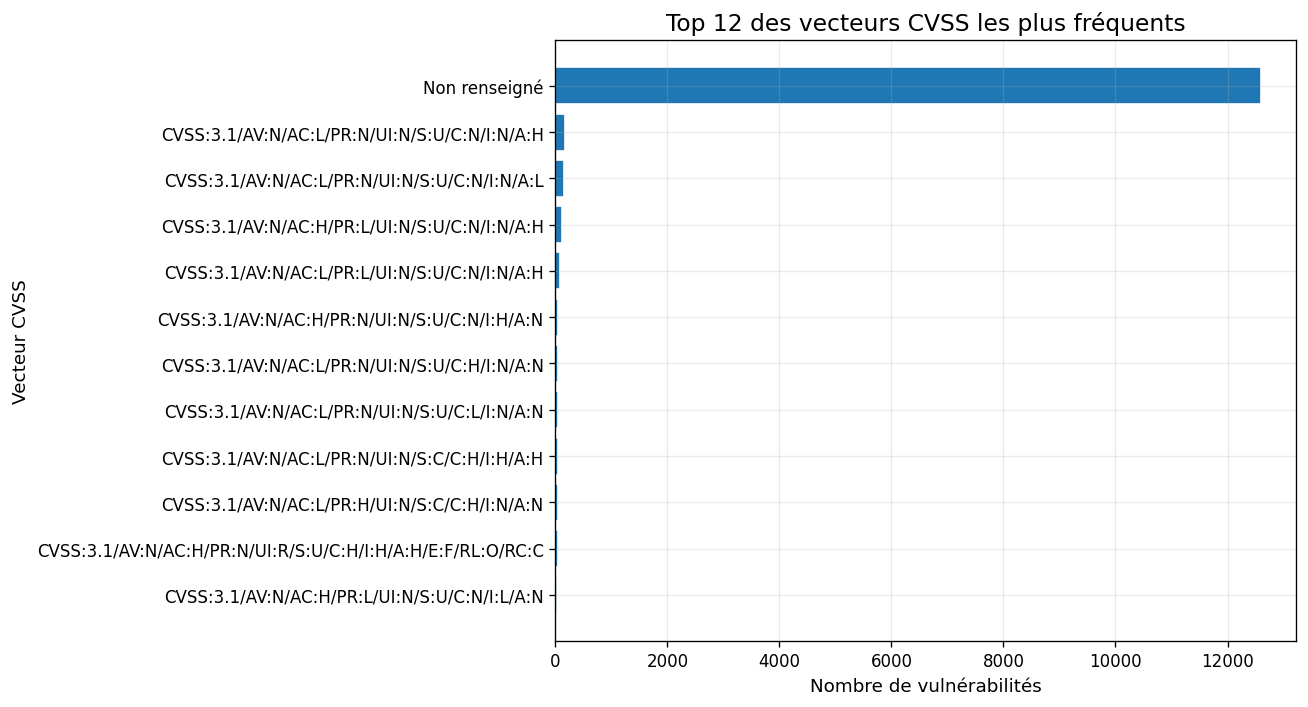

In [34]:
tmp = df["Vecteur_CVSS"].fillna("Non renseigné").astype(str).replace({"": "Non renseigné"})
counts = tmp.value_counts().head(12).sort_values()

plt.figure(figsize=(11, 6), dpi=120)
plt.barh(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title("Top 12 des vecteurs CVSS les plus fréquents")
plt.xlabel("Nombre de vulnérabilités")
plt.ylabel("Vecteur CVSS")
plt.tight_layout()
plt.show()


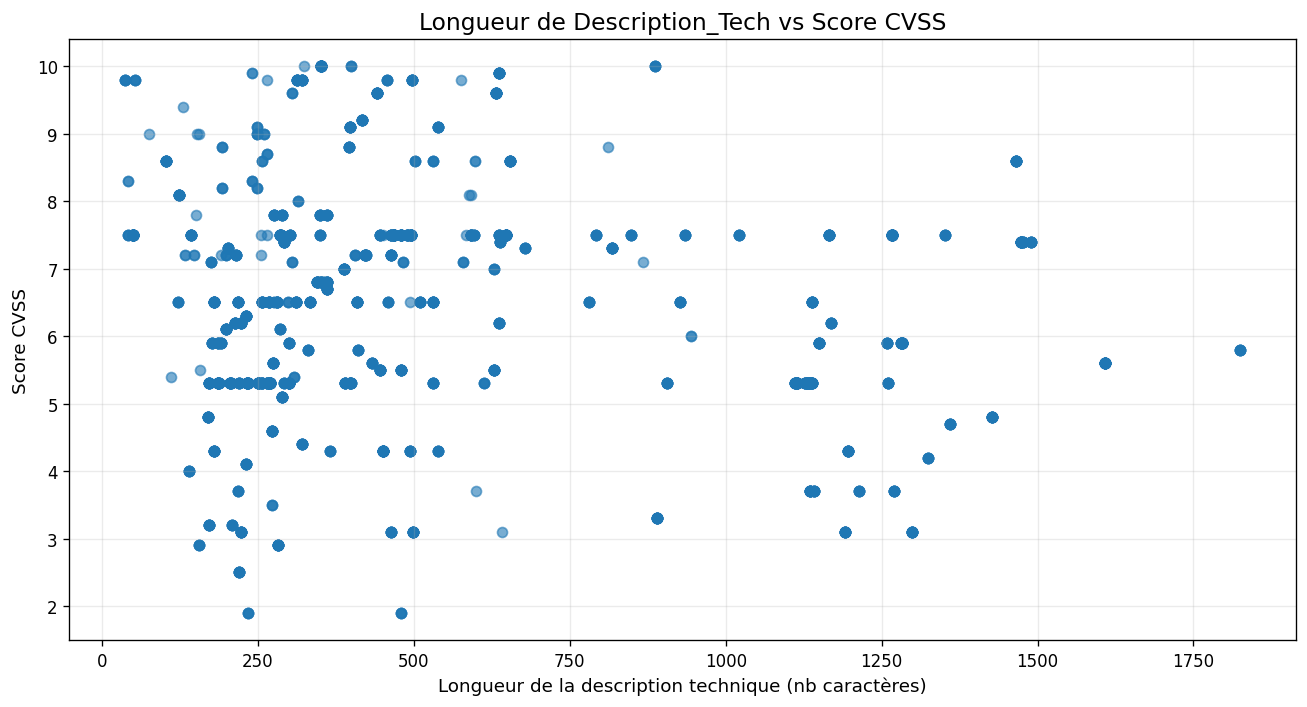

In [35]:
tmp = df[["Description_Tech", "Score_CVSS"]].dropna().copy()
tmp["len_desc"] = tmp["Description_Tech"].astype(str).str.len()

# On coupe les extrêmes pour que le graphe soit lisible (optionnel)
q99 = tmp["len_desc"].quantile(0.99)
tmp = tmp[tmp["len_desc"] <= q99]

plt.figure()
plt.scatter(tmp["len_desc"], tmp["Score_CVSS"], alpha=0.6)
plt.title("Longueur de Description_Tech vs Score CVSS")
plt.xlabel("Longueur de la description technique (nb caractères)")
plt.ylabel("Score CVSS")
plt.tight_layout()
plt.show()


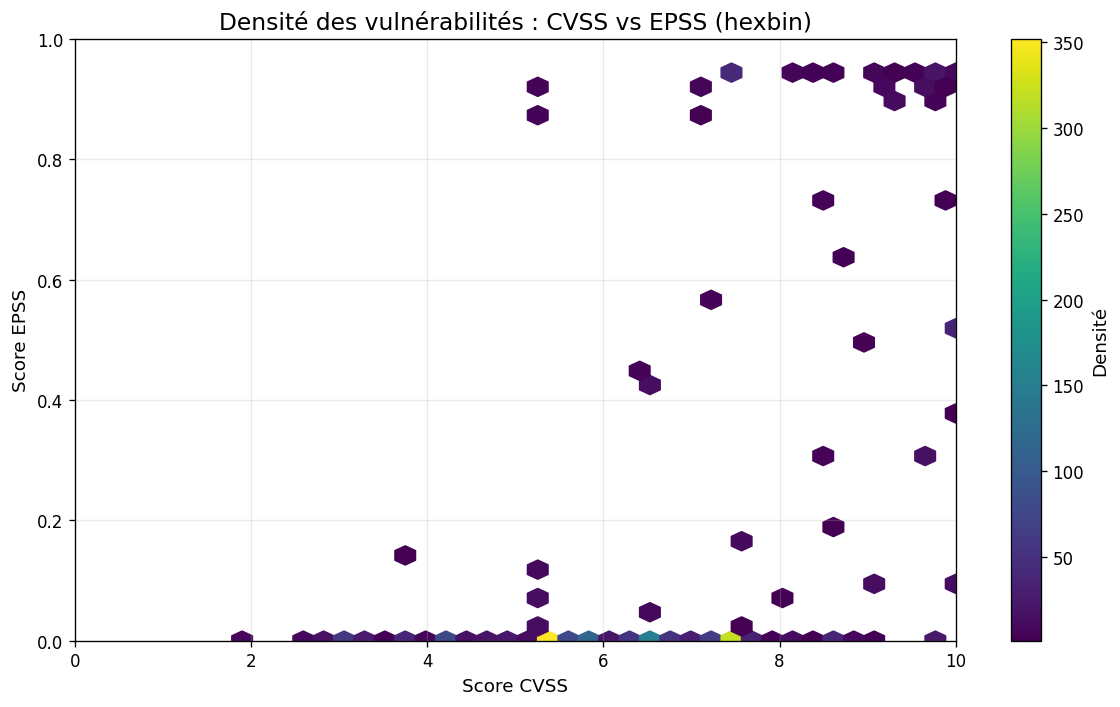

In [39]:
tmp = df[["Score_CVSS", "Score_EPSS"]].dropna()
plt.figure(figsize=(10, 6), dpi=120)
hb = plt.hexbin(tmp["Score_CVSS"], tmp["Score_EPSS"], gridsize=35, mincnt=1)
plt.colorbar(hb, label="Densité")
plt.title("Densité des vulnérabilités : CVSS vs EPSS (hexbin)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.xlim(0, 10)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



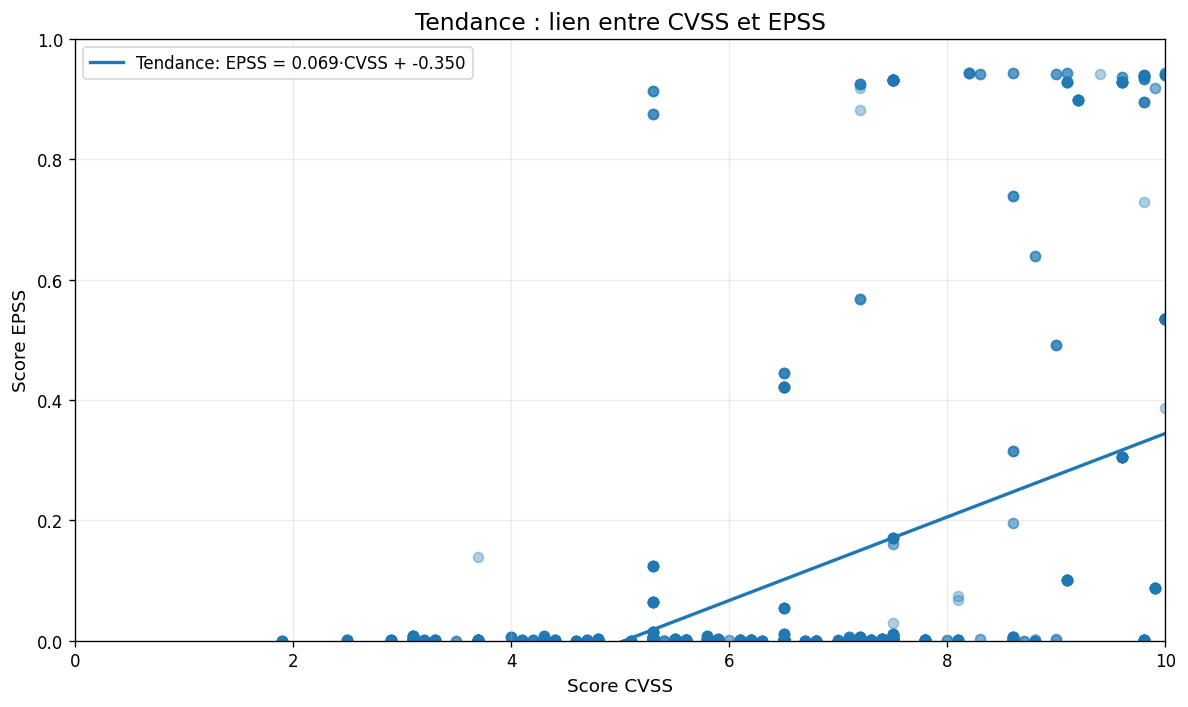

In [40]:
tmp = df[["Score_CVSS", "Score_EPSS"]].dropna()
x = tmp["Score_CVSS"].values
y = tmp["Score_EPSS"].values

# Droite de tendance (moindres carrés)
m, b = np.polyfit(x, y, 1)
xx = np.linspace(0, 10, 200)
yy = m * xx + b

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x, y, alpha=0.35)
plt.plot(xx, yy, linewidth=2, label=f"Tendance: EPSS = {m:.3f}·CVSS + {b:.3f}")
plt.title("Tendance : lien entre CVSS et EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.xlim(0, 10)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


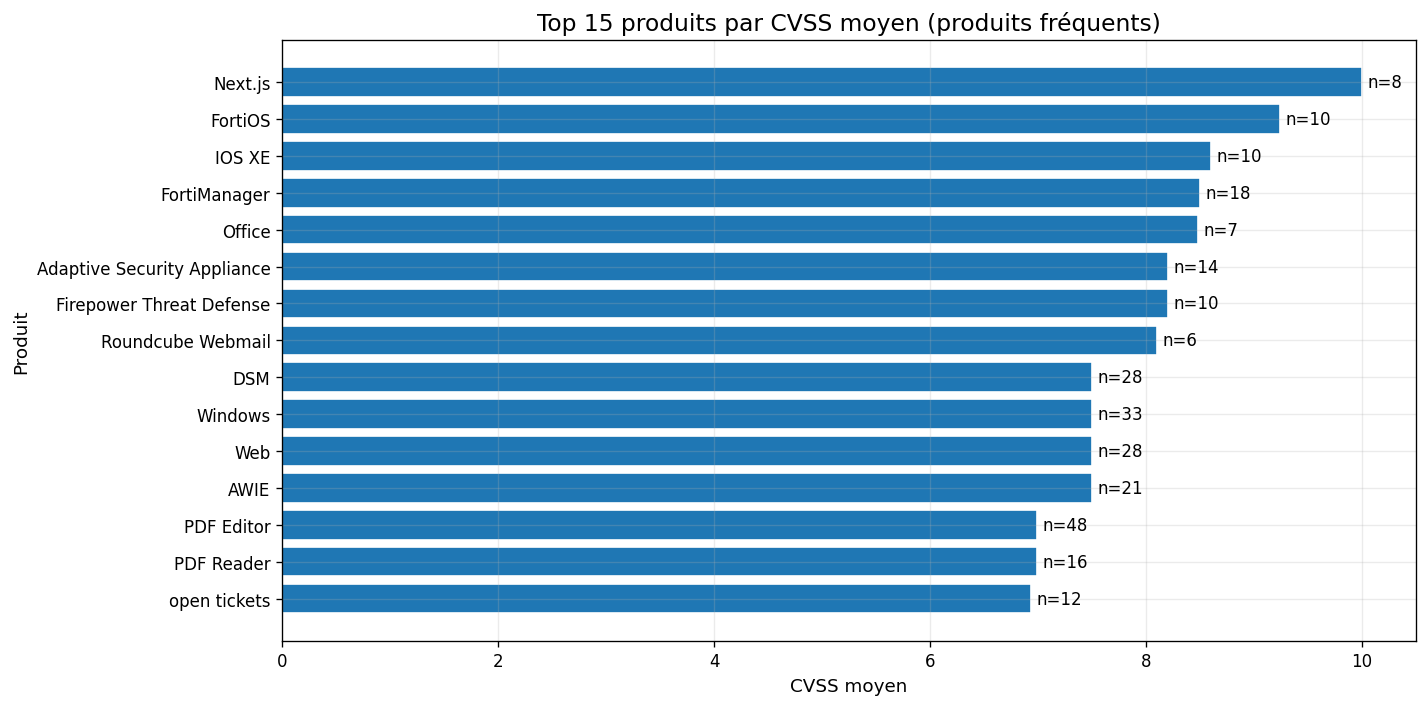

In [41]:
tmp = df[["Produit", "Score_CVSS"]].dropna().copy()
tmp["Produit"] = tmp["Produit"].astype(str).replace({"": "Non renseigné"}).fillna("Non renseigné")

stats = tmp.groupby("Produit")["Score_CVSS"].agg(count="count", mean="mean").reset_index()
stats = stats[stats["count"] >= 5].sort_values("mean", ascending=False).head(15)
stats = stats.sort_values("mean")  # barh

plt.figure(figsize=(12, 6), dpi=120)
bars = plt.barh(stats["Produit"], stats["mean"], edgecolor="white", linewidth=1.0)
plt.title("Top 15 produits par CVSS moyen (produits fréquents)")
plt.xlabel("CVSS moyen")
plt.ylabel("Produit")

# annotations: n=...
for rect, n in zip(bars, stats["count"]):
    plt.text(rect.get_width() + 0.05, rect.get_y() + rect.get_height()/2, f"n={n}", va="center")

plt.tight_layout()
plt.show()


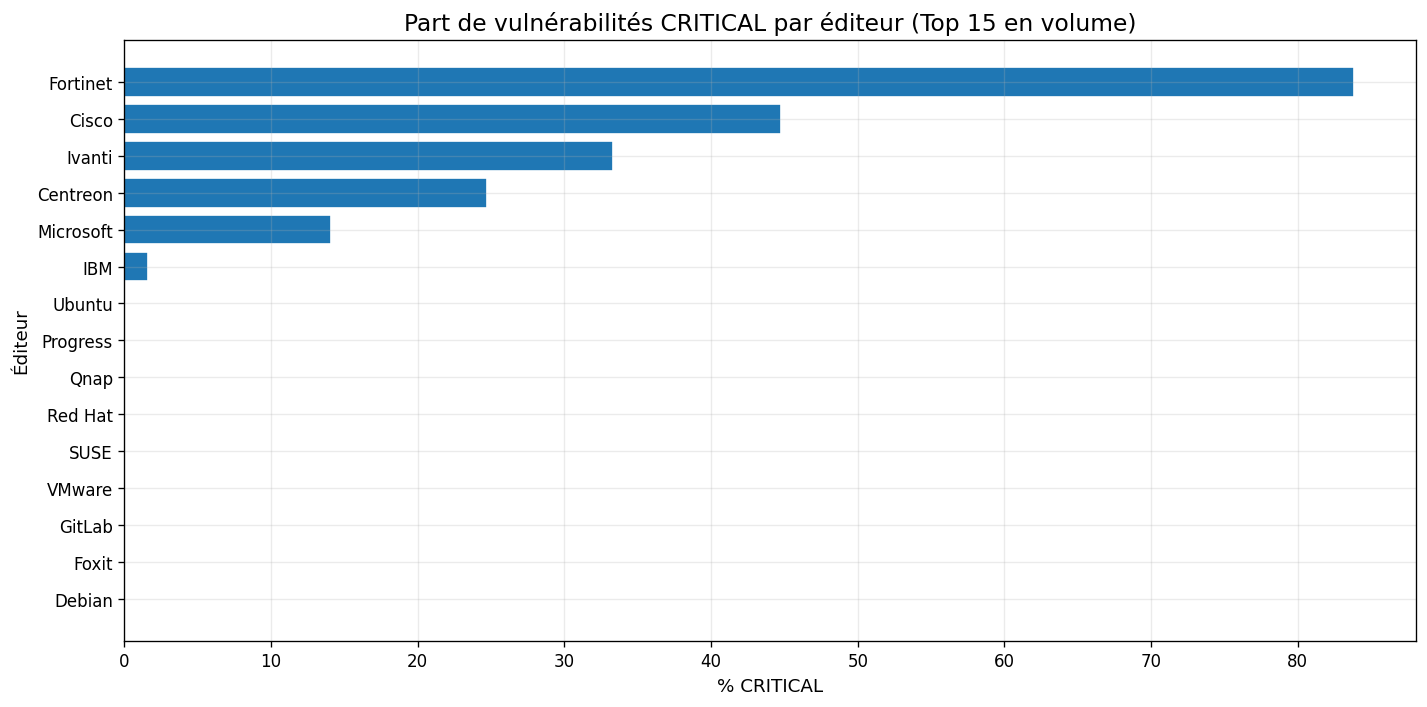

In [42]:
tmp = df[["Éditeur", "Gravite_CVSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()
tmp["Éditeur"] = tmp["Éditeur"].astype(str).replace({"": "Non renseigné"}).fillna("Non renseigné")

# éditeurs les plus présents
top_v = tmp["Éditeur"].value_counts().head(15).index
tmp = tmp[tmp["Éditeur"].isin(top_v)]

rate = tmp.assign(is_critical=(tmp["Gravite_CVSS"] == "CRITICAL")).groupby("Éditeur")["is_critical"].mean()
rate = (rate * 100).sort_values()  # %

plt.figure(figsize=(12, 6), dpi=120)
plt.barh(rate.index, rate.values, edgecolor="white", linewidth=1.0)
plt.title("Part de vulnérabilités CRITICAL par éditeur (Top 15 en volume)")
plt.xlabel("% CRITICAL")
plt.ylabel("Éditeur")
plt.tight_layout()
plt.show()


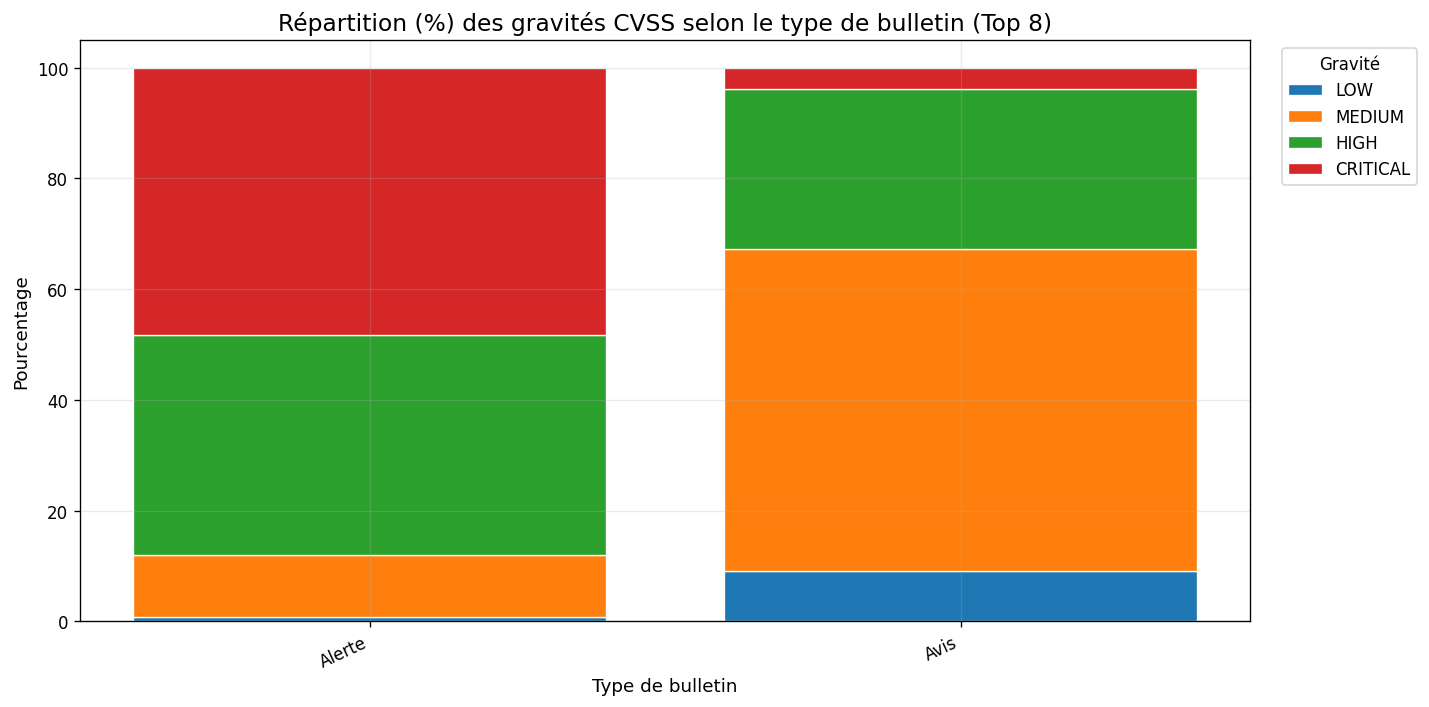

In [43]:
tmp = df[["Type_de_Bulletin", "Gravite_CVSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

top_types = tmp["Type_de_Bulletin"].value_counts().head(8).index
tmp = tmp[tmp["Type_de_Bulletin"].isin(top_types)]

pivot = pd.crosstab(tmp["Type_de_Bulletin"], tmp["Gravite_CVSS"])
for col in ["LOW","MEDIUM","HIGH","CRITICAL"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["LOW","MEDIUM","HIGH","CRITICAL"]]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6), dpi=120)
bottom = np.zeros(len(pivot_pct))
for col in pivot_pct.columns:
    plt.bar(pivot_pct.index, pivot_pct[col].values, bottom=bottom, label=col, edgecolor="white", linewidth=0.8)
    bottom += pivot_pct[col].values

plt.title("Répartition (%) des gravités CVSS selon le type de bulletin (Top 8)")
plt.xlabel("Type de bulletin")
plt.ylabel("Pourcentage")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


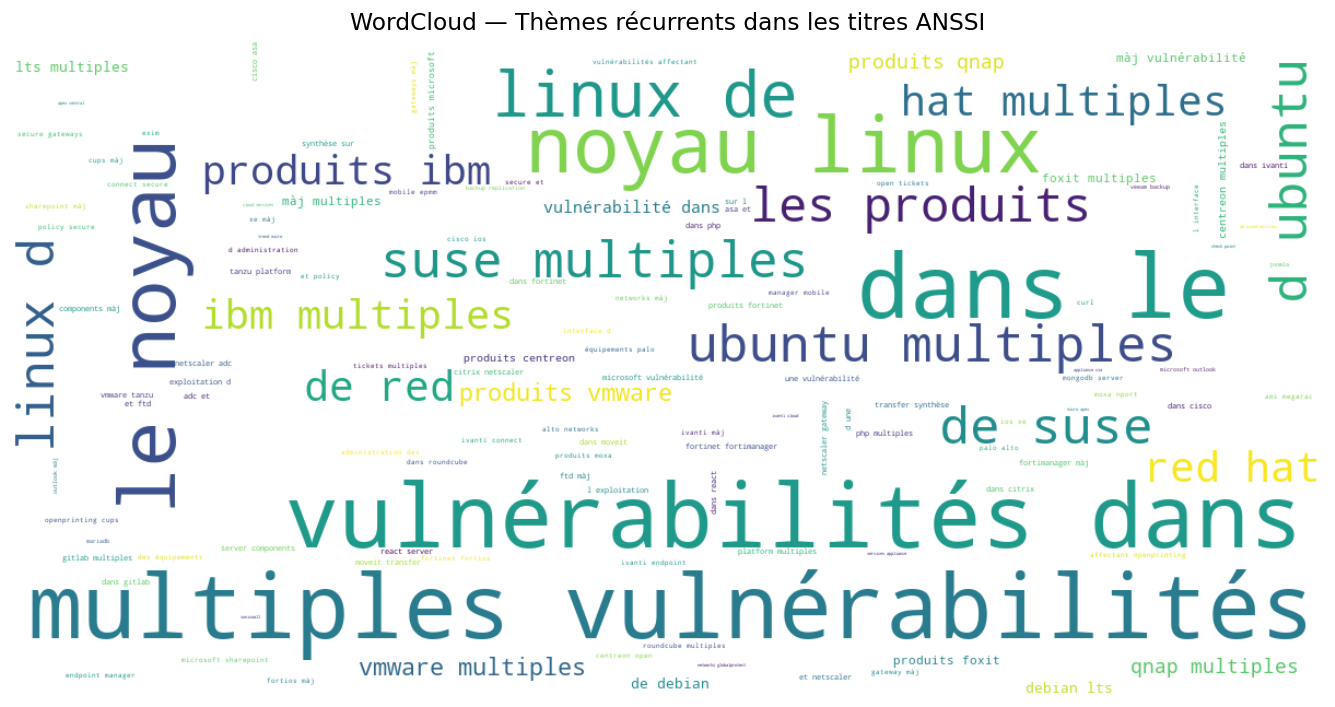

In [46]:
# Optionnel : nécessite wordcloud
from wordcloud import WordCloud

text = (
    df["Titre_ANSSI"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s-]", " ", regex=True)
)

all_text = " ".join(text.tolist())

wc = WordCloud(width=1200, height=600, background_color="white").generate(all_text)

plt.figure(figsize=(12, 6), dpi=120)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Thèmes récurrents dans les titres ANSSI")
plt.tight_layout()
plt.show()
